In [1]:
#import datetime as dt
import cftime 
import time
import datetime
import datetime as dt
import numpy as np
import math as M
import glob
import os
import re
import xarray as xr
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker
from matplotlib.colors import LinearSegmentedColormap, to_rgb
import matplotlib.patheffects as path_effects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

#from matplotlib.offsetbox import AnchoredText
import skimage.measure as sm
from scipy import stats
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial
from scipy.ndimage import gaussian_filter

from metpy import calc as mpcalc
from metpy.units import units
from metpy.plots import Hodograph, SkewT
from metpy.interpolate import interpolate_1d

from subprocess import *
import src.plot_src.ctables as ctables
import colormaps as cmaps


import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
sys.path.append('fsrc/')
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
import ens
import state_vector as state


sys.path.append('/work/jessica.mcdonald/CAM_analysis_tools/filter/')
import RaymondFilters

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

#mpl.rcParams.keys()
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0, 'lines.solid_capstyle':'butt',
                     'axes.labelsize':13, 'axes.titlesize':18, 'ytick.labelsize':13, 'xtick.labelsize':13, 'axes.titleweight':'bold'})

ens2nr = {'UH_2-5km': {25: 46, 50: 94, 75: 141, 100: 182, 125: 226, 150: 268}, 
               'dbz': {30: 8, 35: 16, 40: 24, 45: 32, 50: 40, 55: 48}}


def get_mean_var(files, var, height=None, return_dims=False, return_all_dims=False):
    myvar = []
    for f in files:
        cm1 = xr.open_dataset(f, decode_timedelta=True)
        if height != None:
            zi = findnearest(cm1.zh, height)
            myvar.append(cm1[var][0,zi].values)
        else:
            myvar.append(cm1[var][0].values)
    if return_dims:
        z,y,x = cm1.zh.values, cm1.yh.values, cm1.xh.values
        
    cm1.close()
    meanvar = np.mean(myvar, axis=0)
    
    if return_dims:
        if (height==None) | (return_all_dims==True):
            return z,y,x, meanvar
        else:
            return y,x, meanvar
    else:
        return meanvar


def pmm(cm1, var, height,t, return_mean=False):
    ''' height is in km'''

    N = cm1.sizes['ne']-1
    zi = findnearest(cm1.z, height)

    ens_mean = cm1[var][t, -1,zi]
    ranked_ens =sorted(cm1[var][t, :-1, zi].values.ravel())[::N]
    
    x,y = np.meshgrid(cm1.xh, cm1.yh)
    d = {'ens':ens_mean.values.ravel(), 'x':x.ravel(), 'y':y.ravel()}
    df = pd.DataFrame(d)
    
    df_ranked = df.sort_values(by='ens')
    df_ranked['ens'] = ranked_ens
    
    df_pmm = df_ranked.sort_index()

    if return_mean:
    
        return df_pmm['ens'].values.reshape(np.shape(x)), ens_mean
    else:
        return df_pmm['ens'].values.reshape(np.shape(x))

    
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04, text_bump =0):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k')
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, text_bump+y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13)


def raw_probs(field, threshold, ensN):
   
    probs = np.zeros_like(field)
    probs[field >= threshold] = 1
    return probs.sum(axis=0)/ensN

def performance_diagram(ax, axis_labels=True, colorbar_auto=False, cax = None, cbar_fs = 13, return_colorbar_info = True):

    ax.set_aspect('equal')
    ax.set_xlim(0,1.)
    ax.set_ylim(0,1.)
    
    sr_array = np.linspace(0.001,1,200)
    pod_array = np.linspace(0.001,1,200)
    X,Y = np.meshgrid(sr_array,pod_array)
    csi_vals = (X** -1 + Y ** -1 - 1.) ** -1 
    im = ax.contourf(X,Y,csi_vals,levels=np.arange(0,1.1,0.1),cmap='Greys', alpha=0.3, antialiased=True) #blue_blgra2_r,
    ax.contour(X,Y,csi_vals, levels=[0.2, 0.5, 0.8], colors='0.5', alpha=0.3)

    fb = X/Y
    ax.contour(X,Y,fb,levels=[1],linestyles='--',colors='0.5', linewidths=1)
    bias = ax.contour(X,Y,fb,levels=[0.1,0.5,1,1.5,2,3,5,10],linestyles='--',colors='Grey', linewidths=0.5)
    plt.clabel(bias, inline=True, inline_spacing=2,fmt='%.1f', fontsize=12,colors='0.3')

    if colorbar_auto:
        cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Critical Success Index (CSI)', weight='bold', fontsize=cbar_fs)
        [cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]]
    if cax != None:
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Critical Success Index (CSI)', weight='bold', fontsize=cbar_fs)
        [cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]]
        
    if axis_labels:
        ax.set_xlabel('Success Ratio (1-FAR)')
        ax.set_ylabel('POD')

    if return_colorbar_info:
        return im

def open_exp(path, fcst_start=False):
    fpath = os.path.join(path ,'letkf.exp' )
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'],'%Y-%m-%d %H:%M:%S')
    else:
        with open(os.path.join(path, 'fcst.exp' ), 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['FORECAST']['start'],'%Y-%m-%d %H:%M:%S')

    if fcst_start:
        return exper, f_start
    else:
        return exper

def calc_csi(X, Y):
    return (X** -1 + Y ** -1 - 1.) ** -1 


def rename(exp, version = 'RAW'):
    '''versions are FUll,FULLX, H, V, CI, or RAW'''
    version = version.upper()
    
    if (exp!= 'Control') & (version !='RAW'):
    
        split = exp.split('_')
        ci = split[0]
        hloc = split[1]
        vloc = split[2]
    
        if hloc=='H07':hloc='H7.5'
        #if hloc==9:hloc='9.0'
        
        extra = ''
        if len(split) > 3:extra = f'_{split[3]}'

        if version=='FULLX': name = f'{ci}_{hloc}_{vloc}.5{extra}'
        if version=='FULL':  name = f'{ci}_{hloc}_{vloc}.5'
        if version=='H':     name = f'{ci}_{hloc}'
        if version=='V':     name = f'{ci}_{vloc}.5'
        if version=='CI':    name = f'{ci}'
            
    else:
        if exp == 'Control': name = 'No DA'
        else: name = exp    
    return name

sys.path.append('src/plot_src/')
from ColorblindFilter import colorblind_filter
import wofs_cbook_nowrf as wofs


In [ ]:
import time
while 5<10:
    print('inifiit')
    time.sleep(300)
    

inifiit


6.0
3.0


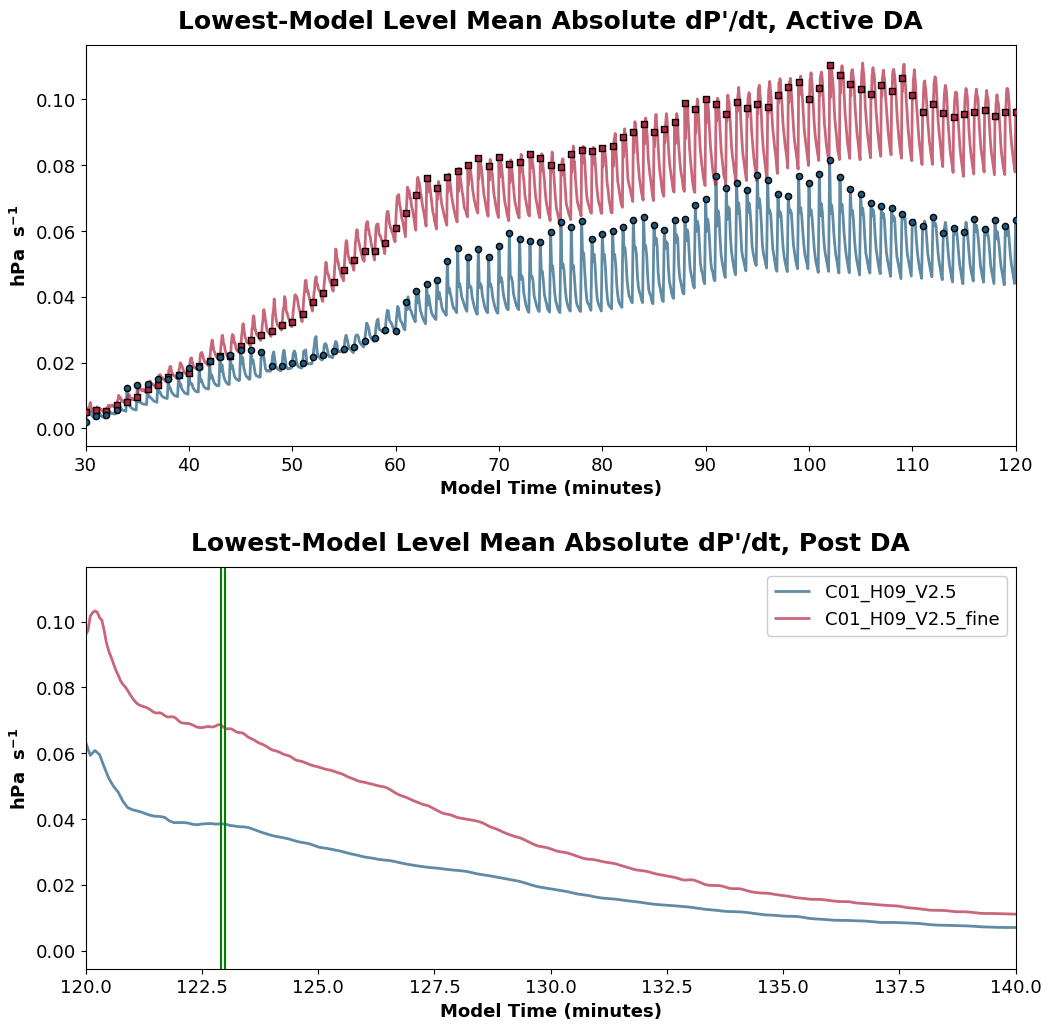

In [52]:


exps = [f'C{h:02d}_H09_V2' for h in [15, 10,3,1]]+['C03_H09_V2_fine']
#exps = ['C03_H09_V2','C03_H09_V2_fine']+['C01_H09_V2','C01_H09_V2_fine']

exps = ['C10_H09_V2','C10_H09_V2_fine']
exps = ['C03_H09_V2','C03_H09_V2_fine']
exps = ['C01_H09_V2','C01_H09_V2_fine']
version='fullx'

mode = 'mean'
member=10


members = np.arange(0, 36, 1)
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

colors = list(cmaps.pride(np.linspace(.17,.78, len(exps))))
if len(exps) == 3: colors = list(cmaps.pride([.2, .6, .8]))
markers = ['o', 's', 'D', 'H','^', '>', '<', 'v']
ls = ['-']*len(exps)


fig,axes = plt.subplots(2,1, figsize=(12, 12))


### WTG




for ax in axes:
    ax.set_xlabel('Model Time (minutes)')
    ax.set_ylabel(r'hPa  s$\mathbf{^{-1}}$');
#axes[1].grid(ls=':', alpha=0.7)



for i,exp in enumerate(exps): 

    # get da times
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    dafreq = exper['DA_PARAMS']['assim_freq']
    dtl  = exper['cm1namelist'][7][-1]
    print(dtl)
    dalen =(dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    peaks = (np.arange(0,dalen+dafreq/2, dafreq )/dtl).astype(int) #+1

    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120) # this will be zero if you used a "pre cooked" set up
    time = wtg.time.values

    if mode == 'mean':
        pten = wtg.divc.values.mean(axis=1)/100
        axes[0].set_title("Lowest-Model Level Mean Absolute dP\'/dt, Active DA", weight='bold', y=1.02)
        axes[1].set_title("Lowest-Model Level Mean Absolute dP\'/dt, Post DA", weight='bold', y=1.02)
    if mode == 'mem':
        pten = wtg.divc.values[:,member]/100
        axes[0].set_title(f"Lowest-Model Level Mean Absolute dP\'/dt for Member {member}, Active DA", weight='bold', y=1.02)
        axes[1].set_title(f"Lowest-Model Level Mean Absolute dP\'/dt for Member {member}, Post DA", weight='bold', y=1.02)



    #### WTG
    zord = 1
    scat=axes[0].scatter(time[i0:i1+1][peaks], pten[i0:i1+1][peaks], color=colors[i], s=20,marker=markers[i], zorder=100*(10-i), ec='k',label=rename(exp, version=version))
    axes[0].plot(time,pten,  color=colors[i], lw=2,label=rename(exp, version=version), alpha=0.7, zorder=zord, ls=ls[i])
    axes[1].plot(time,pten,  color=colors[i], lw=2,label=rename(exp, version=version), alpha=0.7, zorder=zord, ls=ls[i])
    
axes[1].legend(fontsize=13, loc='upper right')

# for li in np.arange(30,183, 3):
#     axes[1].axvline(li, color='k', alpha=0.3)
#     axes[0].axvline(li, color='k', alpha=0.3)


# for li in np.arange(30, 130, 10):
    
#     axes[0].axvline(li, color='k', alpha=0.3)

#     adj = 175/60
#     axes[0].axvline(li+adj, color='k', alpha=0.3)
#     axes[0].axvline(li+(adj*2), color='k', alpha=0.3)
#     axes[0].axvline(li+(adj*3), color='k', alpha=0.3)
    

axes[0].set_xlim(30,120)


#axes[0].set_xlim(50,53)
axes[1].set_xlim(120, 140)

plt.subplots_adjust(hspace=0.3)

# axes[1].axvline(120 + (133.5/60), color='r')

# axes[1].axvline(120 + (12/60), color='b')
# axes[1].axvline(120 + (12/60)+ (133.5/60), color='b')

axes[1].axvline(120 + (175/60), color='g')
axes[1].axvline(120 + (180/60), color='g')

In [45]:
np.arange(0,dalen+dafreq/2, dafreq )

array([   0.,   60.,  120.,  180.,  240.,  300.,  360.,  420.,  480.,
        540.,  600.,  660.,  720.,  780.,  840.,  900.,  960., 1020.,
       1080., 1140., 1200., 1260., 1320., 1380., 1440., 1500., 1560.,
       1620., 1680., 1740., 1800., 1860., 1920., 1980., 2040., 2100.,
       2160., 2220., 2280., 2340., 2400., 2460., 2520., 2580., 2640.,
       2700., 2760., 2820., 2880., 2940., 3000., 3060., 3120., 3180.,
       3240., 3300., 3360., 3420., 3480., 3540., 3600., 3660., 3720.,
       3780., 3840., 3900., 3960., 4020., 4080., 4140., 4200., 4260.,
       4320., 4380., 4440., 4500., 4560., 4620., 4680., 4740., 4800.,
       4860., 4920., 4980., 5040., 5100., 5160., 5220., 5280., 5340.,
       5400.])

In [47]:
N_steps = int(dalen/dafreq)


90.0

In [48]:
peaks = (np.arange(0,dalen+dafreq/2, dafreq )/dtl).astype(int)
peaks

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250,
       260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380,
       390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510,
       520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640,
       650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770,
       780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900])

/tmp/ipykernel_1406452/1170481745.py:91: RuntimeWarning: divide by zero encountered in divide
  ax[2].semilogy(1/f, Pxx, label="Original")
/tmp/ipykernel_1406452/1170481745.py:92: RuntimeWarning: divide by zero encountered in divide
  ax[2].semilogy(1/f, Pxx_clean, label="DA-subtracted")


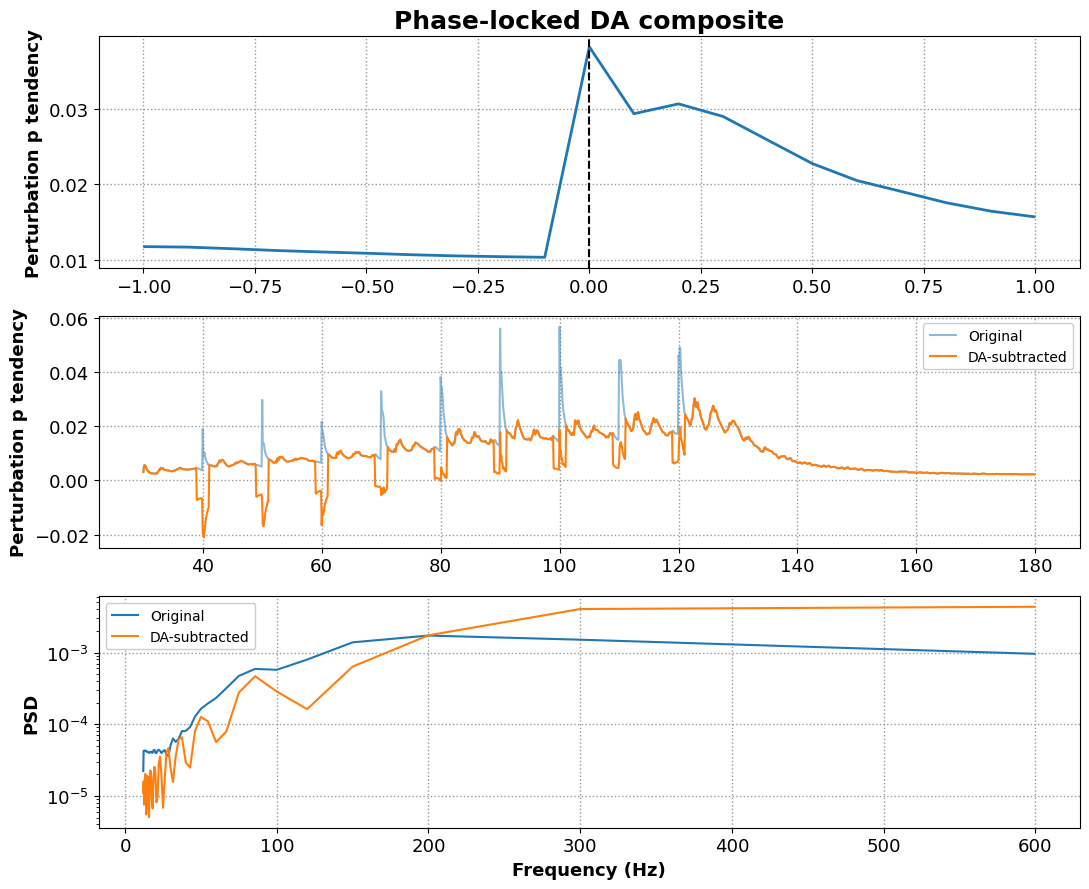

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==================================================
# USER SETTINGS
# ==================================================
x = pten[i0:].copy()
t = time[i0:].copy()*60
DA_times = time[i0:][peaks].copy() * 60

dt = np.median(np.diff(t))        # sampling interval (s)

pre_time = 60.0                 # seconds before DA
post_time = 60.0                # seconds after DA

# Welch PSD settings
nperseg = int(600 / dt)

# ==================================================
# BUILD PHASE-LOCKED DA COMPOSITE
# ==================================================
lags = np.arange(-pre_time, post_time + dt, dt)
nlag = len(lags)

segments = []

for t0 in DA_times:
    idx0 = np.argmin(np.abs(t - t0))

    i1 = idx0 - int(pre_time / dt)
    i2 = idx0 + int(post_time / dt) + 1

    if i1 < 0 or i2 > len(x):
        continue

    segments.append(x[i1:i2])

segments = np.array(segments)

# Phase-locked DA composite
DA_composite = np.mean(segments, axis=0)

# ==================================================
# SUBTRACT COMPOSITE FROM FULL TIME SERIES
# ==================================================
x_clean = x.copy()
counts = np.zeros_like(x)

for t0 in DA_times:
    idx0 = np.argmin(np.abs(t - t0))

    i1 = idx0 - int(pre_time / dt)
    i2 = idx0 + int(post_time / dt) + 1

    if i1 < 0 or i2 > len(x):
        continue

    x_clean[i1:i2] -= DA_composite
    counts[i1:i2] += 1

# Optional: average where DA windows overlap
mask = counts > 0
x_clean[mask] = x_clean[mask] / counts[mask]

# ==================================================
# PLOTTING
# ==================================================
fig, ax = plt.subplots(3, 1, figsize=(11, 9))

# ---- Panel 1: DA composite ----
ax[0].plot(lags / 60, DA_composite, lw=2)
ax[0].axvline(0, color='k', ls='--')
ax[0].set_ylabel("Perturbation p tendency")
ax[0].set_title("Phase-locked DA composite")
ax[0].grid(True)

# ---- Panel 2: Time series ----
ax[1].plot(t / 60, x, label="Original", alpha=0.5)
ax[1].plot(t / 60, x_clean, label="DA-subtracted", lw=1.5)
ax[1].set_ylabel("Perturbation p tendency")
ax[1].legend()
ax[1].grid(True)

# ---- Panel 3: Welch PSD ----
fs = 1.0 / dt

f, Pxx = welch(x, fs, nperseg=nperseg, detrend="linear")
_, Pxx_clean = welch(x_clean, fs, nperseg=nperseg, detrend="linear")

ax[2].semilogy(1/f, Pxx, label="Original")
ax[2].semilogy(1/f, Pxx_clean, label="DA-subtracted")
ax[2].set_xlabel("Frequency (Hz)")
ax[2].set_ylabel("PSD")
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()


6.0
12.0
10.100224696399662
6.0
10.666666666666666
9.719400604950327
6.0
12.400000000000007
9.128019323933769
6.0
12.2
11.257913719302033


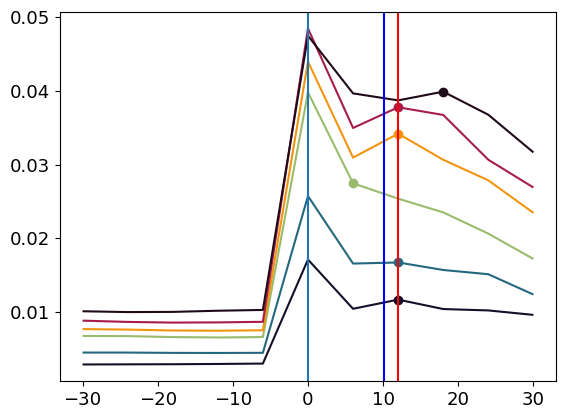

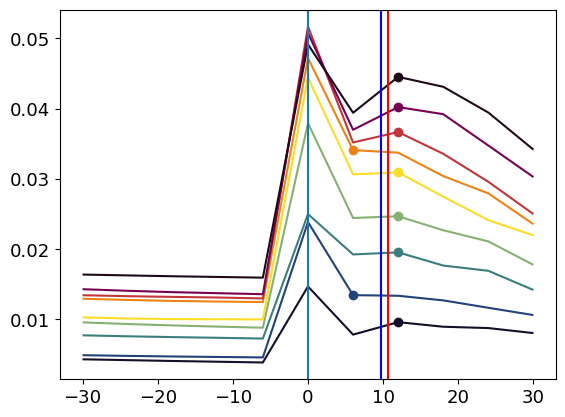

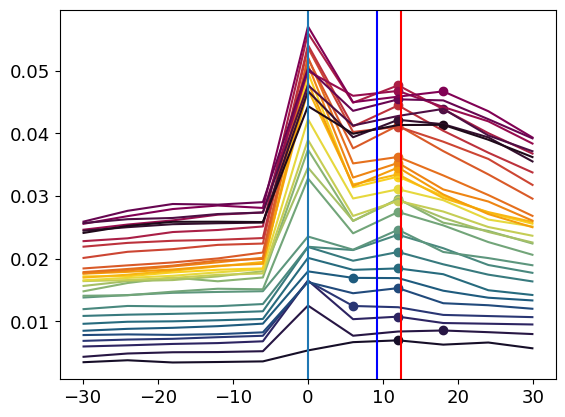

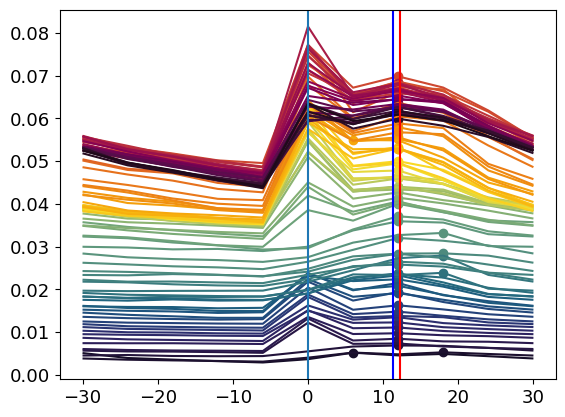

In [290]:
# make a plot that is centered on each DA time step
exps = ['C01_H09_V2_fine','C01_H09_V2']




#exps = ['C03_H09_V2_fine','C03_H09_V2']
#exps = ['C01_H09_V2']
mode='mean'
member=0


exps = [f'C{h:02d}_H09_V2' for h in [15, 10,3,1]]

for i,exp in enumerate(exps): 

    fig = plt.figure()

    # get da times
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    dafreq = exper['DA_PARAMS']['assim_freq']
    dtl  = exper['cm1namelist'][7][-1]
    print(dtl)
    dalen =(dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120) # this will be zero if you used a "pre cooked" set up
    time = wtg.time.values * 60 


    peaks = i0+ (np.arange(0,dalen+dafreq/2, dafreq )/dtl).astype(int)[1:] # add i0 so you can index whole array

    if mode == 'mean':
        pten = wtg.divc.values.mean(axis=1)/100
    if mode == 'mem':
        pten = wtg.divc.values[:,member]/100


    buf = int(30/dtl) # 30 seconds

    peak_times = time[peaks]
    colors = cmaps.pride(np.linspace(0,1, len(peak_times)))

    secondary_peak_time = []

    for i,p in enumerate(peaks):

        centered_time = time[p-buf : p+buf+1].copy()-peak_times[i]
        centered_pten = pten[p-buf : p+buf+1].copy()#- np.mean(pten[p-buf : p+buf+1].copy())


        
        plt.plot(centered_time, centered_pten , color=colors[i])

        
        centered_time_rhs = centered_time[buf+1:]
        centered_pten_rhs = centered_pten[buf+1:]

        ti = np.argmax(centered_pten_rhs)
        plt.scatter(centered_time_rhs[ti], centered_pten_rhs[ti], color=colors[i])
        secondary_peak_time.append(centered_time_rhs[ti])

    plt.axvline(np.mean(secondary_peak_time), color='r')
    print(np.mean(secondary_peak_time))


    ds = xr.open_dataset(f"{fpath}{exp}/AllPrior_Post.nc", decode_timedelta=True)
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
    times = [(pd.Timestamp(t)-start).seconds/60 for t in ds.time.values]     
    
    
    # obs heights
    
    height1, count1 = get_weighted_height(ds, 'DBZ')
    height2, count2 = get_weighted_height(ds,  'DBZ0')
    height3, count3 = get_weighted_height(ds, 'VR')
    
    hmean = (height1*count1 + height2*count2 + height3*count3)/(count1+count2+count3)
    est_bounce = np.nanmean((hmean+100)/343)
    print(est_bounce)
    plt.axvline(est_bounce, color='b')
    

    
    plt.axvline(0)


In [306]:
def quick_norm(a):
    return (a-np.nanmin(a))/(np.nanmax(a)-np.nanmin(a))

In [54]:
def get_var(myds, var, kind, t=None, tf=None, mem=None, keep_dim=True, drop_outliers=True, drop_inliers=False):
    ''' returns a single variable. for a single data type. Keep_dim means you keep the time dimension.
        if t == None, whole dataset returned. if mem=None, all members returned (and dimensions are retained)
        if t!= None but tf == None, then only a single index (t) is returned. Else, a slice between t and tf is returned.'''

    ds = myds.copy()

    if drop_outliers:
        variable = ds[var].values
        variable[ds.outlier.values>3] = np.nan
        if drop_inliers:
            variable[ds.outlier.values<0.25] = np.nan

        if ((var== 'Hxf') | (var== 'Hxf_post')):
            ds[var] = (('t', 'n', 'ne'), variable)
        else:
            ds[var] = (('t', 'n'), variable)
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))
    
    if t!= None:
        if tf == None:tf = t+1
        ds = ds.isel(t=slice(t,tf))
    
    if len(ds.t)==1:
        ds = ds.isel(n=ds[kind].values[0])
        mydata = ds[var].values
        mydata = mydata[np.isnan(mydata) == False]
    
    if (len(ds.t)>1) & (keep_dim==False):
        mydata = ds[var].values[ds[kind].values]
        mydata = mydata[np.isnan(mydata) == False]
    
    
    if (len(ds.t)>1) & (keep_dim) & ((var!= 'Hxf') & (var!= 'Hxf_post')):  
        temp = []
        sizes = []
    
        mydata = np.zeros([len(ds.t), 100000])*np.nan
    
        for i in range(len(ds.t)):
           
            v = ds[var].values[i][ds[kind].values[i]]
            sizes.append(len(v))
            mydata[i, :len(v)] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
    
    if (len(ds.t)>1) & (keep_dim) & ((var== 'Hxf') | (var== 'Hxf_post')) :  
        temp = []
        sizes = []
    
        if mem !=None: mydata = np.zeros([len(ds.t), 100000])*np.nan
        else:  mydata = np.zeros([len(ds.t), 100000, len(ds.ne)])*np.nan
        for i in range(len(ds.t)):
            for n in range(len(ds.ne)):
                v = ds[var].values[i,:,n][ds[kind].values[i]]
                sizes.append(len(v))
                mydata[i, :len(v), n] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
        

    return np.array(mydata)

def get_weighted_height(ds, var, mode='mean', member=0):

    if mode == 'mean':
        hxf = get_var(ds, 'Hxfbar', var,  drop_outliers=True)[1:,:]
        hxfp = get_var(ds, 'Hxfbar_post', var,  drop_outliers=True)[1:,:]

    if mode == 'mem':
        hxf = get_var(ds, 'Hxf', var,  drop_outliers=True)[1:,:, member]
        hxfp = get_var(ds, 'Hxf_post', var,  drop_outliers=True)[1:,:, member]

    
    
    weight = abs((hxf+100)-(hxfp+100)) # make sure there's no issue with VR, add 100 to get above zero
    
    height = get_var(ds, 'z', var,  drop_outliers=True)[1:,:]
    
    weighted_height = np.nansum(height*weight, axis=1) / np.nansum(weight, axis=1)

    non_nan_mask = ~np.isnan(height)
    count = np.sum(non_nan_mask, axis=1)
    return weighted_height, count

In [ ]:
exps = [f'C{h:02d}_H09_V2' for h in [15, 10,3,1]] 

C10_H09_V2 12.0


NameError: name 'get_weighted_height' is not defined

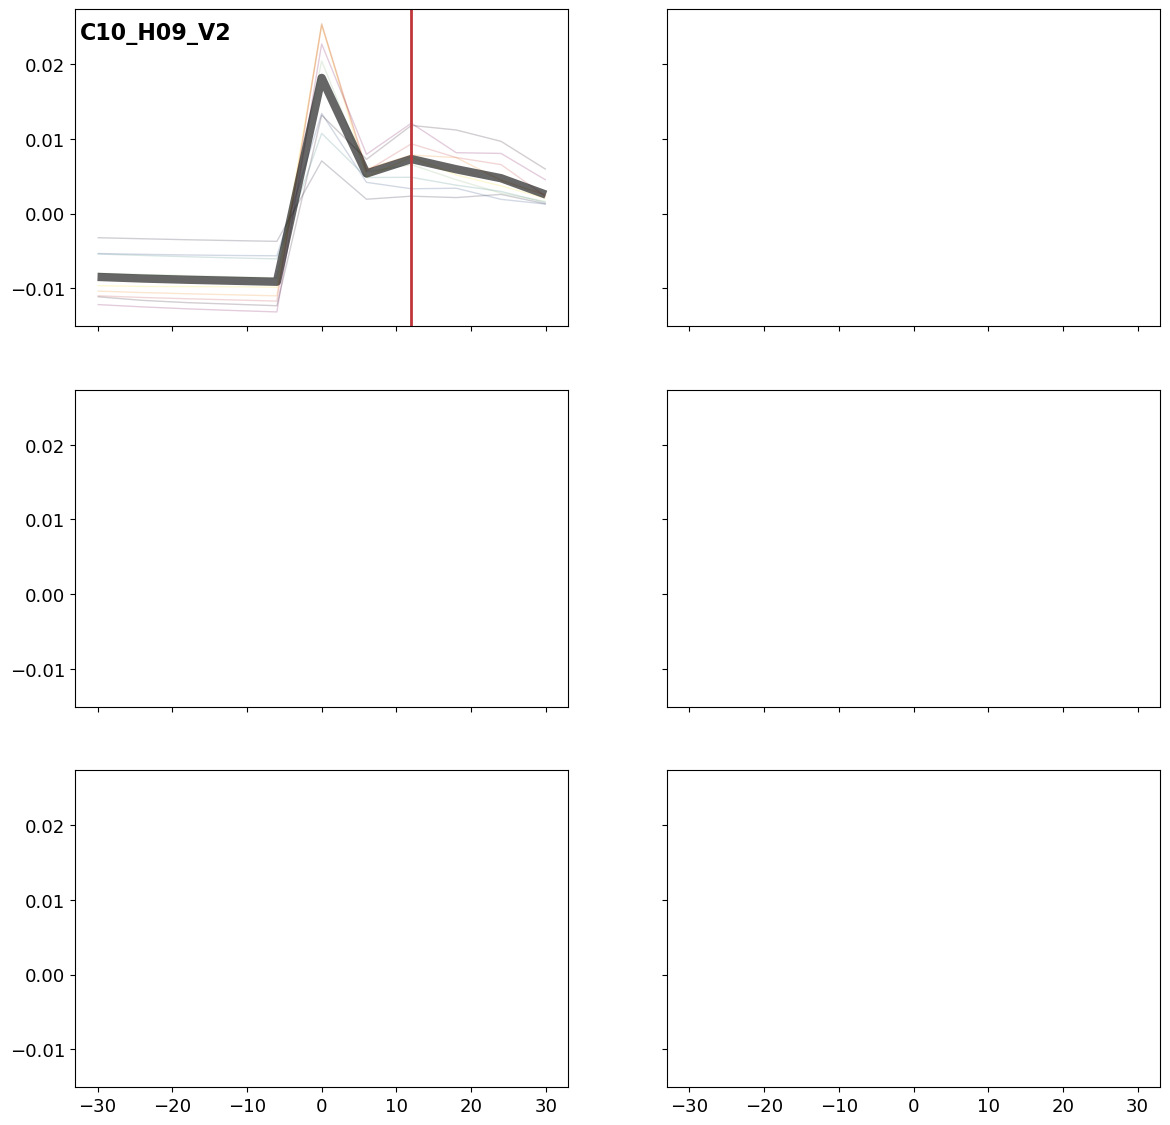

In [2]:
# make a plot that is centered on each DA time step
exps = ['C01_H09_V2_fine','C01_H09_V2']
#exps = ['C03_H09_V2_fine','C03_H09_V2']
#exps = ['C01_H09_V2']
mode='mean'
member=0


exps = [f'C{h:02d}_H09_V2' for h in [15, 10,3,1]] #+ ['C03_H09_V2_fine','C01_H09_V2_fine']
exps = ['C10_H09_V2']
names = ['15 min Cycling', '10 min Cycling', '3 min Cycling', '1 min Cycling', '3 min Cycling (1.5 km)', '1 min Cycling (1.5 km)']

exps = ['C10_H09_V2','C10_H09_V2_fine', 'C03_H09_V2','C03_H09_V2_fine', 'C01_H09_V2','C01_H09_V2_fine']
names = ['15 min Cycling', '10 min Cycling', '3 min Cycling', '1 min Cycling', '3 min Cycling (1.5 km)', '1 min Cycling (1.5 km)']

names = [rename(exp, version='raw') for exp in exps]


fig, axes = plt.subplots(3,2, figsize=(14,14), sharex=True, sharey=True)
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

for i,exp in enumerate(exps): 

    # get da times
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    dafreq = exper['DA_PARAMS']['assim_freq']
    dtl  = exper['cm1namelist'][7][-1]
    
    #print(dtl)
    dalen =(dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')-dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')).seconds
    

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
    i1=findnearest(wtg.time.values, 120) # this will be zero if you used a "pre cooked" set up
    time = wtg.time.values * 60 


    peaks = i0+ (np.arange(0,dalen+dafreq/2, dafreq )/dtl).astype(int)[1:] # add i0 so you can index whole array

    if mode == 'mean':
        pten = wtg.divc.values.mean(axis=1)/100
    if mode == 'mem':
        pten = wtg.divc.values[:,member]/100


    buf = int(30/dtl) # 30 seconds

    peak_times = time[peaks]
    colors = cmaps.pride(np.linspace(0,1, len(peak_times)))

    secondary_peak_time = []

    pten_arr = []

    ax = axes.flatten()[i]
    
    for pi,p in enumerate(peaks):

        centered_time = time[p-buf : p+buf+1].copy()-peak_times[pi]
        centered_pten = pten[p-buf : p+buf+1].copy()- np.mean(pten[p-buf : p+buf+1].copy())
        #centered_pten = quick_norm(pten[p-buf : p+buf+1].copy())

        pten_arr.append(centered_pten)


        
        ax.plot(centered_time, centered_pten , color=colors[pi], alpha=0.2, lw=1)

        
        # centered_time_rhs = centered_time[buf+1:]
        # centered_pten_rhs = centered_pten[buf+1:]

        # ti = np.argmax(centered_pten_rhs)
        # ax.scatter(centered_time_rhs[ti], centered_pten_rhs[ti], color=colors[pi], alpha=0.3)
        # secondary_peak_time.append(centered_time_rhs[ti])

    ax.plot(centered_time, np.nanmean(pten_arr, axis=0), color='k', lw=6, alpha=0.6, label='Mean Norm. dp/dt')

    # new - find secondary peak using the average 
    pten_rhs = np.nanmean(pten_arr, axis=0)[buf+1:]
    # centered_time_rhs = 
    #ti = 
    
    second_peak = centered_time[buf+1:][np.argmax(pten_rhs)]
    print(exp, second_peak)
    ax.axvline(second_peak, label='Mean 2nd Peak Time', color=cmaps.pride(0.75), lw=2)


    #ax.set_title(label=rename(exp, version=version), loc='left', y=.88, x=.01, fontsize=16)
    ax.set_title(names[i], loc='left', y=.88, x=.01, fontsize=16)


    
    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    
    
    
    # obs heights

    ds = xr.open_dataset(f"{fpath}{exp}/AllPrior_Post.nc", decode_timedelta=True)
    
    height1, count1 = get_weighted_height(ds, 'DBZ' , mode=mode,member=member )
    height2, count2 = get_weighted_height(ds, 'DBZ0', mode=mode,member=member )
    height3, count3 = get_weighted_height(ds, 'VR'  , mode=mode,member=member)
    ds.close()
    
    hmean = (height1*count1 + height2*count2 + height3*count3)/(count1+count2+count3)
    est_bounce = np.nanmean((hmean+100)/343)
    
    ax.axvline(est_bounce, color=cmaps.pride(0.15), label='Est. 2nd Peak Time', lw=2)
    diffs = abs(second_peak - est_bounce)

    blended_trans_x_data = mpl.transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(second_peak+1,0.05, f'diff = {diffs:.2f} s', fontsize=14, weight='bold', transform = blended_trans_x_data )

    for t in np.arange(centered_time[0], centered_time[-1]+dtl, dtl):
        ax.axvline(t,color='k', alpha=0.2, lw=0.5)
    

    
    ax.axvline(0, color='k', ls='--', alpha=0.4)

#axes[0,0].legend(loc=2, fontsize=14)
plt.subplots_adjust(wspace=0.03, hspace=0.06)

fig.suptitle("Psuedo-Normalized dP\'/dt, Centered on DA Times", fontsize=24, weight='bold', y=.97)

fig.text(0.5, 0.06, 'Time from DA (s)', ha='center', va='center', fontsize=18, weight='bold')

handles, labels = axes[0,0].get_legend_handles_labels() 
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, .94), ncol=3, fontsize=16)


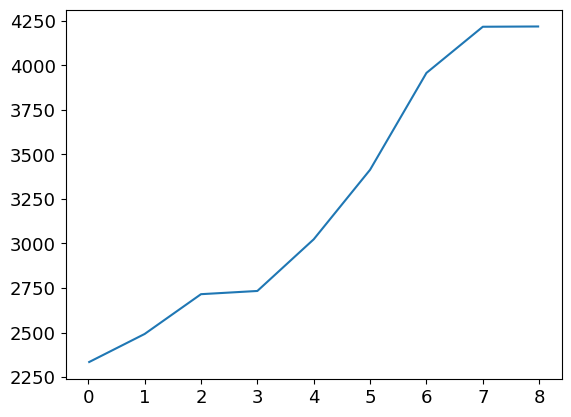

In [18]:
height1, count1 = get_weighted_height(ds, 'DBZ' , mode=mode,member=member )
height2, count2 = get_weighted_height(ds, 'DBZ0', mode=mode,member=member )
height3, count3 = get_weighted_height(ds, 'VR'  , mode=mode,member=member)
ds.close()

hmean = (height1*count1 + height2*count2 + height3*count3)/(count1+count2+count3)
#est_bounce = np.nanmean((hmean+100)/343)

plt.plot(hmean)

In [19]:
total_dist = (25000 - np.mean(hmean)) + 24000 #up to the top and down to 100 m AGL, ignoring damping region 
total_dist/343


                          

np.float64(133.42928744169689)

In [9]:
25000-4000 # 21000 m up, 24000 m back

21000

/tmp/ipykernel_338075/367422942.py:58: RuntimeWarning: divide by zero encountered in divide
  plt.semilogy(1/freq_l, psd_l)
/tmp/ipykernel_338075/367422942.py:59: RuntimeWarning: divide by zero encountered in divide
  plt.semilogy(1/freq_s, psd_s)
/tmp/ipykernel_338075/367422942.py:60: RuntimeWarning: divide by zero encountered in divide
  plt.semilogy(1/freq, psd)


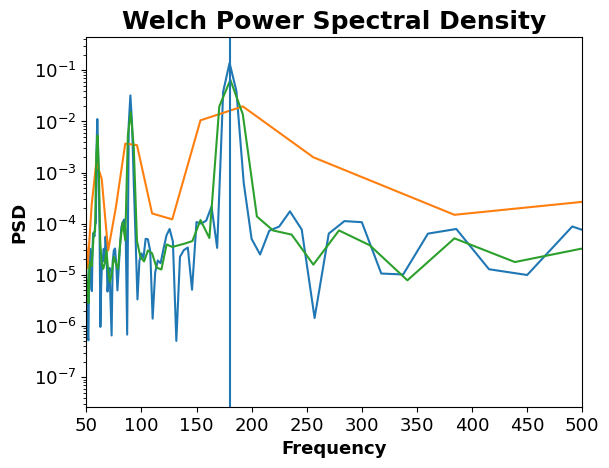

In [72]:


# Example
         # sampling interval
fs = 1 / dtl        # sampling frequency

i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up
i1=findnearest(wtg.time.values, 120) # this will be zero if you used a "pre cooked" set up



# Short-period PSD
freq_s, psd_s = welch(
    x_detrended[i0:i1],
    fs=fs,
    nperseg=256,
    noverlap=126
)

# Long-period PSD
freq_l, psd_l = welch(
    x_detrended[i0:i1],
    fs=fs,
    nperseg=len(x_detrended[i0:i1]),
    noverlap=0
)


plt.figure()
plt.semilogy(1/freq_l, psd_l)
plt.semilogy(1/freq_s, psd_s)
plt.semilogy(1/freq, psd)
plt.xlabel("Frequency")
plt.ylabel("PSD")
plt.title("Welch Power Spectral Density")

plt.xlim(50, 500)
plt.axvline(dafreq)

In [22]:
from scipy.signal import welch
def Welch_PSD(data, freq, detrend=True, drop_zero=True):

    if detrend:
        freq_psd, psd = welch(data,fs=freq,window='hann',nperseg=len(data), detrend='linear') 
    #     data -= data.mean()
    else:
        freq_psd, psd = welch(data,fs=freq,window='hann',nperseg=len(data)) 
        
    # note, I tested smaller AND larger nperseg, the peaks don't change much 
    # but 256 loses the exact location of the PSD peaks (they're too broad)

    
        

    
    if drop_zero:
        valid = (freq_psd > 0)
    
        return freq_psd[valid], psd[valid]
    else:
        return freq_psd, psd
    

C03_H09_V2
180
C03_H09_V2_fine
180


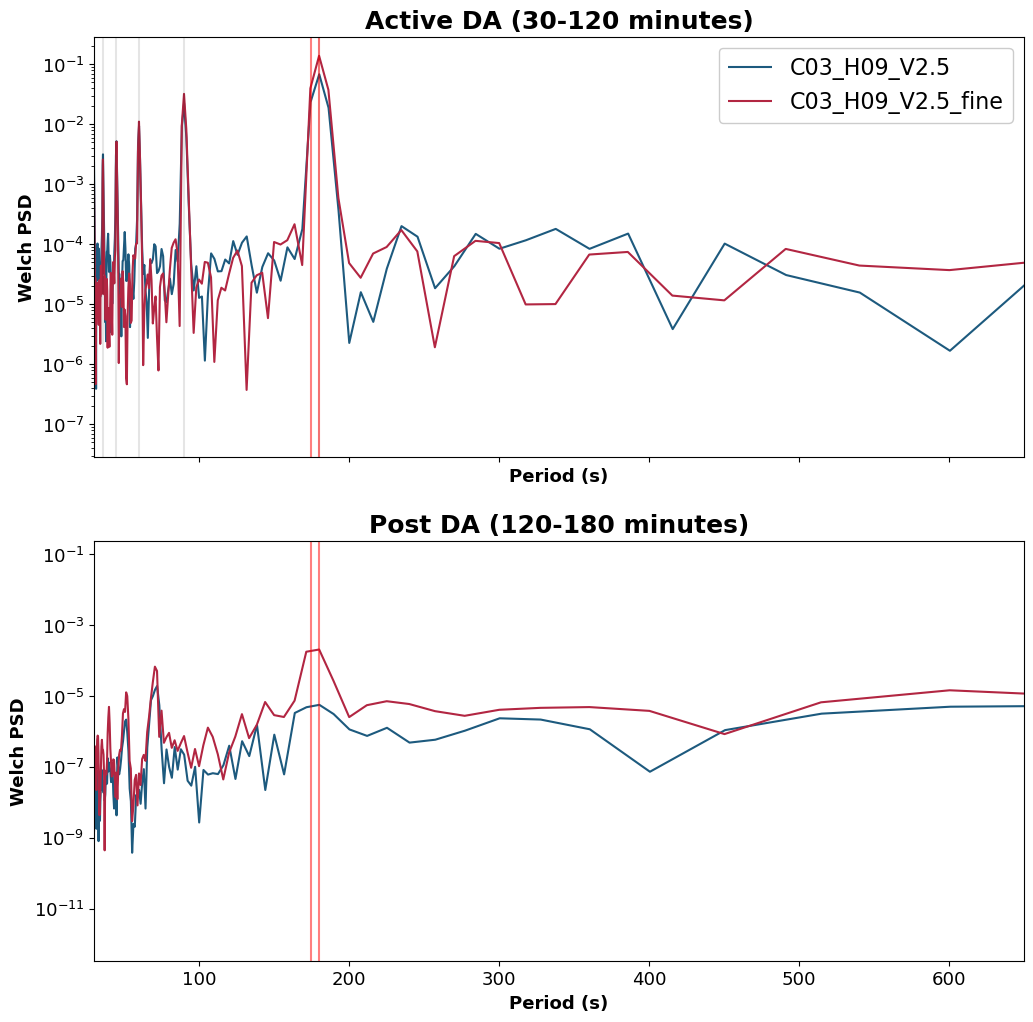

In [34]:
member = 0

exps = [f'C{h:02d}_H09_V2' for h in [15, 10,3,1]]

fig, axes = plt.subplots(2,1, figsize=(12, 12), sharex=True)

exps = ['C10_H09_V2']

exps = ['C10_H09_V2','C10_H09_V2_fine']
exps = ['C03_H09_V2','C03_H09_V2_fine']
# exps = ['C01_H09_V2','C01_H09_V2_fine']

# exps = ['C03_H09_V2_fine','C01_H09_V2_fine']

# exps = ['C01_H09_V2','C01_H09_V2_fine']

version='fullx'

mode = 'mean'
member=10

colors = list(cmaps.pride(np.linspace(.17,.78, len(exps))))

fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

for i,exp in enumerate(exps): 
    print(exp)

    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    dafreq = exper['DA_PARAMS']['assim_freq']
    dtl  = exper['cm1namelist'][7][-1]
   
    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30)
    i1=findnearest(wtg.time.values, 120)
    i2=findnearest(wtg.time.values, 180)

    pten = wtg.divc.values[:,member]/100

    pten_da   = pten[i0:i1+1].copy()
    pten_post = pten[i1:i2+1].copy()

    print(dafreq)
    freq, psd = Welch_PSD(pten_da.copy(), 1/dtl, detrend=True)
    axes[0].semilogy(1/freq, psd, color=colors[i], label=rename(exp, version=version))

    
    freq, psd = Welch_PSD(pten_post.copy(), 1/dtl, detrend=True)
    axes[1].semilogy(1/freq, psd, color=colors[i])

    wtg.close()



# plt.semilogy(1/freq, psd)
# plt.xlabel("Frequency")
# plt.ylabel("PSD")
axes[0].set_title("Active DA (30-120 minutes)")
axes[1].set_title("Post DA (120-180 minutes)")   
    
axes[0].legend(fontsize=16)
    

for li in np.arange(1, 20):
    axes[0].axvline(dafreq/li, color='k', alpha=0.1)


for ax in axes:
    ax.axvline(175, color='r', alpha=0.5)
    ax.axvline(180, color='r', alpha=0.5)
    ax.set_ylabel('Welch PSD')
    ax.set_xlabel('Period (s)')
    ax.set_xlim(30,650)

plt.subplots_adjust(hspace=.2)

In [115]:
import numpy as np

def bicoherence(x, fs, nperseg):
    """
    Compute bicoherence using segment averaging.
    Returns frequencies f and bicoherence matrix b2.
    """
    x = x - np.mean(x)
    n = nperseg
    step = n // 2

    segments = []
    for start in range(0, len(x) - n + 1, step):
        seg = x[start:start+n]
        seg = seg * np.hanning(n)
        X = np.fft.rfft(seg)
        segments.append(X)

    Xs = np.array(segments)
    nseg = Xs.shape[0]

    freqs = np.fft.rfftfreq(n, 1/fs)
    nf = len(freqs)

    B = np.zeros((nf, nf), dtype=complex)
    P12 = np.zeros((nf, nf))
    P3 = np.zeros((nf, nf))

    for k1 in range(nf):
        for k2 in range(nf - k1):
            prod = Xs[:, k1] * Xs[:, k2]
            B[k1, k2] = np.mean(prod * np.conj(Xs[:, k1 + k2]))
            P12[k1, k2] = np.mean(np.abs(prod)**2)
            P3[k1, k2] = np.mean(np.abs(Xs[:, k1 + k2])**2)

    b2 = np.abs(B)**2 / (P12 * P3)
    return freqs, b2


fs = 1 / dtl
nperseg = 256   # similar logic as Welch

f, b2 = bicoherence(pten_da.copy(), fs, nperseg)

/tmp/ipykernel_379953/1449964784.py:36: RuntimeWarning: invalid value encountered in divide
  b2 = np.abs(B)**2 / (P12 * P3)


(0.0, 0.08333333333333333)

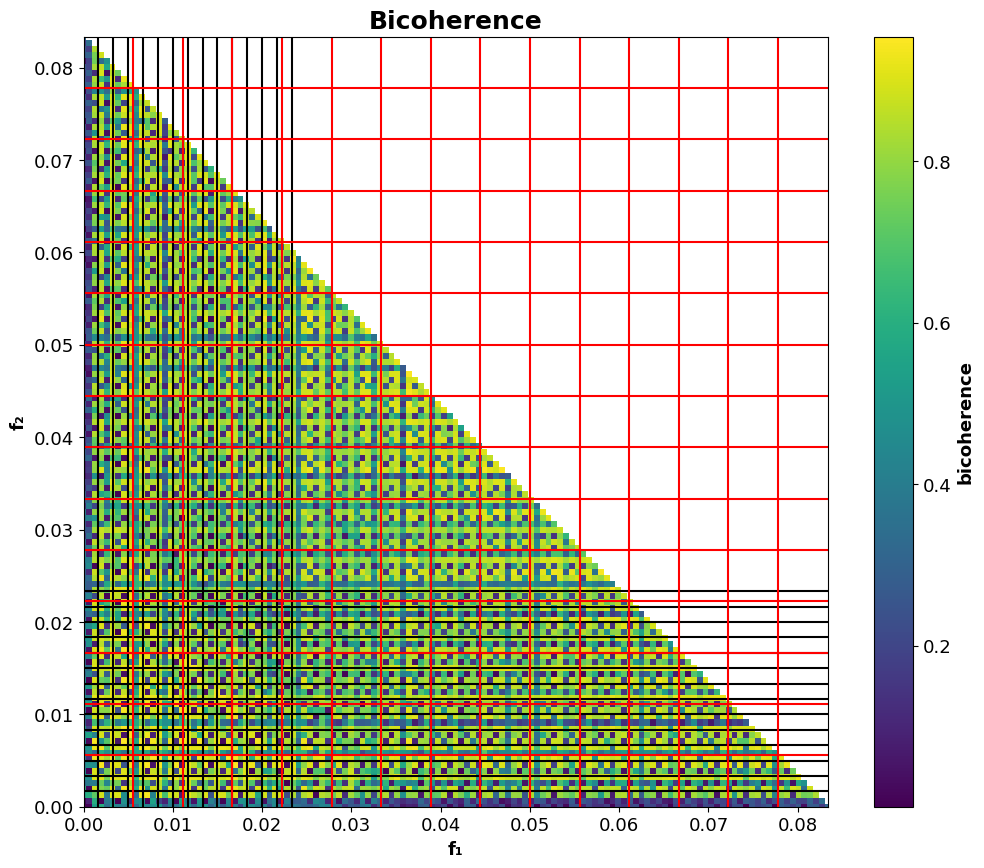

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.pcolormesh(f, f, b2, shading='auto')
plt.xlabel("f₁")
plt.ylabel("f₂")
plt.colorbar(label="bicoherence")
plt.title("Bicoherence")
#plt.show()

for a in np.arange(1,15):
    ff = a*(1/dafreq)
    plt.axvline(ff, color='k')
    plt.axhline(ff, color='k')


for a in np.arange(1,15):
    ff = a*(1/180)
    plt.axvline(ff, color='r')
    plt.axhline(ff, color='r')

plt.xlim(f.min(), f.max())
plt.ylim(f.min(), f.max())



In [392]:
exps = [f'C{h:02d}_H09_V2' for h in [15, 10,3,1]]


exps = ['C03_H09_V2_fine','C03_H09_V2','C01_H09_V2_fine','C01_H09_V2']
names = ['DA_3min_fine', 'DA_3min', 'DA_1min_fine', 'DA_1min']

version='fullx'

mode = 'mem'
member=0#10

x_dict = {}

fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

for i,exp in enumerate(exps): 
    print(exp)

    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    dafreq = exper['DA_PARAMS']['assim_freq']
    dtl  = exper['cm1namelist'][7][-1]
   
    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30)
    i1=findnearest(wtg.time.values, 120)

   # pten = wtg.divc.values[:,:].mean(axis=1)/100

    pten = wtg.divc.values[:,member]/100

    pten_da = pten[i0:].copy()
    #x_dict[f'DA_{int(exp[1:3])}min'] = pten_da
    x_dict[names[i]] = pten_da
    wtg.close()

C03_H09_V2_fine
C03_H09_V2
C01_H09_V2_fine
C01_H09_V2


In [133]:
x_dict.keys()

dict_keys(['DA_15min', 'DA_10min', 'DA_3min', 'DA_1min'])

/tmp/ipykernel_4053038/3726720515.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_4053038/3726720515.py:136: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


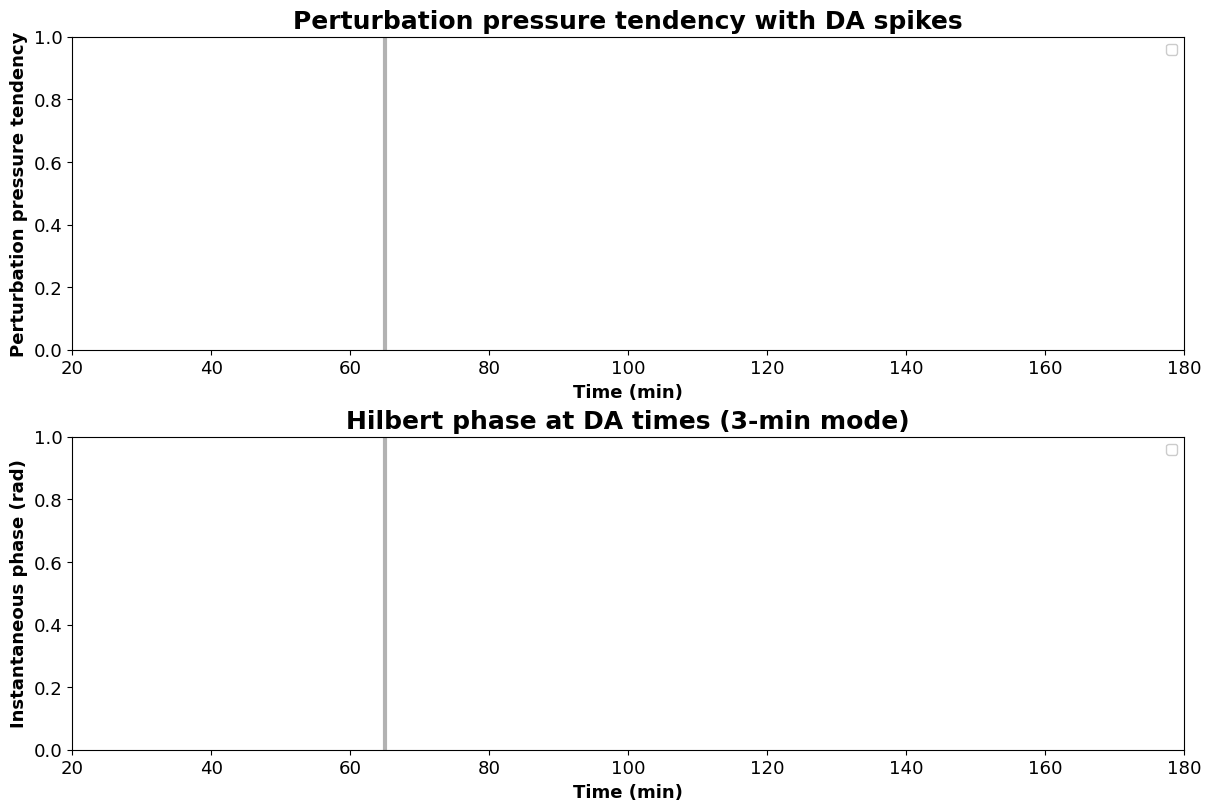

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, hilbert, butter, filtfilt

# ======================
# USER INPUTS
# ======================
# x_dict = {  # replace with your arrays
#     'DA_1min': x1,
#     'DA_3min': x3,
#     'DA_10min': x10,
#     'DA_15min': x15
# }

colors = list(cmaps.pride(np.linspace(.17,.78, len(exps))))

time = (wtg.time.values[i0:])*60#-wtg.time.values[i0])*60
da_period_dict = {'DA_1min':60, 'DA_3min':180, 'DA_10min':600, 'DA_15min':900} # seconds


da_period_dict = {'DA_1min':60, 'DA_3min':180, 'DA_1min_fine':60, 'DA_3min_fine':180,} # seconds


fs = 1/(time[1]-time[0])  # sampling frequency in Hz

# Sliding PSD parameters
window_sec = 600  # 10 min window
noverlap = 0.5    # 50% overlap
nperseg = int(window_sec*fs)

# Bandpass filter for Hilbert phase around intrinsic 3-min mode
lowcut = 2/60     # 2 min period -> Hz
highcut = 5/60    # 5 min period -> Hz

# Bicoherence parameters
bic_nperseg = 256

# ----------------------
# HELPER FUNCTIONS
# ----------------------
# def bandpass_filter(x, low, high, fs, order=4):
#     b,a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
#     return filtfilt(b, a, x)

def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs / 2.0
    low = lowcut / nyq
    high = highcut / nyq
    
    if high >= 1.0:
        high=0.99999
        #raise ValueError(f"Highcut {highcut} Hz is above Nyquist {nyq} Hz")
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, x)

def bicoherence(x, fs, nperseg):
    """Compute bicoherence using segment averaging."""
    x = x - np.mean(x)
    n = nperseg
    step = n//2
    segments = []
    for start in range(0, len(x)-n+1, step):
        seg = x[start:start+n] * np.hanning(n)
        X = np.fft.rfft(seg)
        segments.append(X)
    Xs = np.array(segments)
    nseg = Xs.shape[0]
    nf = Xs.shape[1]
    B = np.zeros((nf,nf), dtype=complex)
    P12 = np.zeros((nf,nf))
    P3 = np.zeros((nf,nf))
    for k1 in range(nf):
        for k2 in range(nf-k1):
            prod = Xs[:,k1]*Xs[:,k2]
            B[k1,k2] = np.mean(prod * np.conj(Xs[:,k1+k2]))
            P12[k1,k2] = np.mean(np.abs(prod)**2)
            P3[k1,k2] = np.mean(np.abs(Xs[:,k1+k2])**2)
    b2 = np.abs(B)**2 / (P12*P3)
    freqs = np.fft.rfftfreq(n, 1/fs)
    return freqs, b2

# ======================
# FIGURE SETUP
# ======================
fig, axes = plt.subplots(2,1, figsize=(12,8), constrained_layout=True)
#colors = ['C0','C1','C2','C3']

# --- Panel A: Time series ---
ax = axes[0]
for i, key in enumerate(x_dict):
    ax.plot(time/60, x_dict[key], color=colors[i], label=key)
    da_t = np.arange(time[0], time[-1], da_period_dict[key])
    # for t in da_t:
    #     ax.axvline(t/60, color=colors[i], alpha=0.2)
ax.set_ylabel("Perturbation pressure tendency")
ax.set_xlabel("Time (min)")
ax.set_title("Perturbation pressure tendency with DA spikes")
ax.legend()

# # --- Panel B: Sliding-window PSD ---
# ax = axes[1]
# for i, key in enumerate(x_dict):
#     x = x_dict[key]
#     Sxx_list = []
#     times_list = []
#     step = int(nperseg*(1-noverlap))
#     for start in range(0, len(x)-nperseg+1, step):
#         seg = x[start:start+nperseg]
#         f, Pxx = welch(seg, fs=fs, nperseg=nperseg)
#         Sxx_list.append(Pxx)
#         times_list.append(time[start+nperseg//2]/60)
#     Sxx = np.array(Sxx_list).T
#     im = ax.pcolormesh(times_list, f*60, 10*np.log10(Sxx), shading='auto', cmap='viridis')
# ax.set_ylabel("Frequency (1/min)")
# ax.set_xlabel("Time (min)")
# ax.set_title("Panel B: Sliding-window PSD")
# fig.colorbar(im, ax=ax, label='Power (dB)')

# --- Panel C: Hilbert phase ---
ax = axes[1]
for i, key in enumerate(x_dict):
    x = x_dict[key]
    x_filt = bandpass_filter(x, lowcut, highcut, fs)
    analytic_signal = hilbert(x_filt)
    inst_phase = np.angle(analytic_signal)
    da_t = np.arange(time[0], 120*60, da_period_dict[key])
    da_idx = np.searchsorted(time, da_t)

    mask = da_t > 120/60

    ax.plot(da_t/60, inst_phase[da_idx], color=colors[i],alpha=0.2)
    ax.scatter(da_t/60, inst_phase[da_idx], color=colors[i], label=key, s=20)
ax.set_ylabel("Instantaneous phase (rad)")
ax.set_xlabel("Time (min)")
ax.set_title("Hilbert phase at DA times (3-min mode)")
ax.legend()

# # --- Panel D: Bicoherence ---
# ax = axes[3]
# for i, key in enumerate(x_dict):
#     x = x_dict[key]
#     f_bi, b2 = bicoherence(x, fs, bic_nperseg)
#     # Only show frequency range near DA and 3-min mode
#     mask = (f_bi*60 >= 0.5) & (f_bi*60 <= 5)  # 0.5–5 min periods
#     im = ax.pcolormesh(f_bi[mask]*60, f_bi[mask]*60, b2[np.ix_(mask,mask)],
#                        shading='auto', cmap='inferno', alpha=0.6)
# ax.set_xlabel("f1 (1/min)")
# ax.set_ylabel("f2 (1/min)")
# ax.set_title("Panel D: Bicoherence (nonlinear coupling)")
# fig.colorbar(im, ax=ax, label='Bicoherence')




for ax in axes:
    ax.axvline(65, color='k', alpha=0.3, lw=3)
    ax.set_xlim(20, 180)
plt.show()


C01_H09_V2
C01_H09_V2_fine


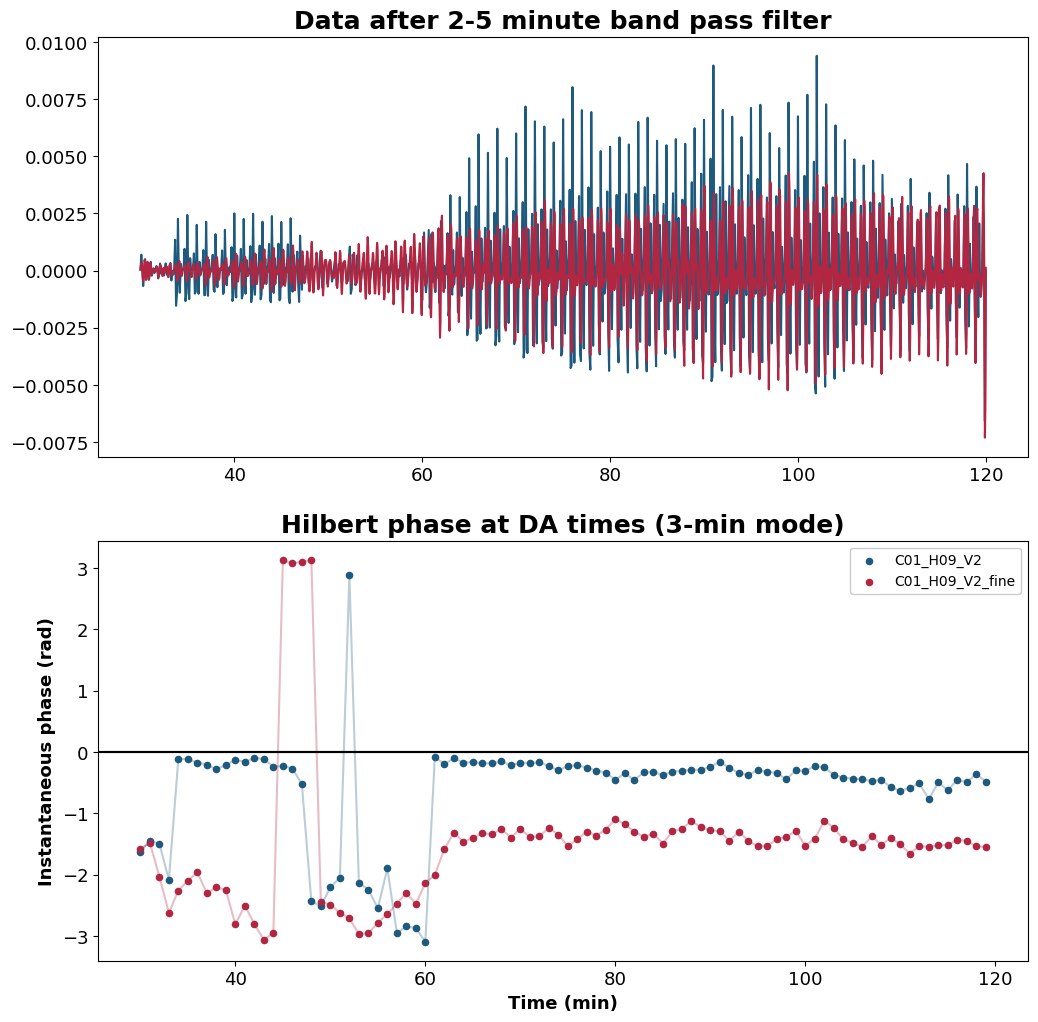

In [65]:

exps = ['C15_H09_V2','C10_H09_V2','C03_H09_V2','C03_H09_V2_fine','C01_H09_V2','C01_H09_V2_fine']
exps = ['C03_H09_V2','C03_H09_V2_fine']#,'C01_H09_V2','C01_H09_V2_fine']
exps = ['C01_H09_V2','C01_H09_V2_fine']

fig, axes = plt.subplots(2,1, figsize=(12,12))
colors = list(cmaps.pride(np.linspace(.17,.78, len(exps))))

version='fullx'

mode = 'mem'
member=0#10

x_dict = {}

fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'

for i,exp in enumerate(exps): 
    print(exp)

    with open(f'{fpath}{exp}/letkf.exp', 'rb') as f:exper= json.load(f)
    dafreq = exper['DA_PARAMS']['assim_freq']
    dtl  = exper['cm1namelist'][7][-1]
   
    # read in and process data

    wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
    i0=findnearest(wtg.time.values, 30)
    i1=findnearest(wtg.time.values, 120)

    x = wtg.divc.values[i0:i1+1,:].mean(axis=1)/100
    time = wtg.time[i0:i1+1].values*60

    fs = 1/(time[1]-time[0])  # sampling frequency in Hz

    # # Sliding PSD parameters
    # window_sec = 600  # 10 min window
    # noverlap = 0.5    # 50% overlap
    # nperseg = int(window_sec*fs)
    
    # Bandpass filter for Hilbert phase around intrinsic 3-min mode
    lowcut = 2/60     # 2 min period -> Hz
    highcut = 4/60    # 5 min period -> Hz
    
    # # Bicoherence parameters
    # bic_nperseg = 256


 
    x_filt = bandpass_filter(x, lowcut, highcut, fs)
    analytic_signal = hilbert(x_filt)
    inst_phase = np.angle(analytic_signal)
    da_t = np.arange(time[0], time[-1], dafreq)
    da_idx = np.searchsorted(time, da_t)
    axes[1].plot(da_t/60, inst_phase[da_idx], color=colors[i], alpha=0.3)
    axes[1].scatter(da_t/60, inst_phase[da_idx], color=colors[i], label=exp, s=20)

    axes[0].plot(time/60,x_filt, color=colors[i])
    axes[1].axhline(0, color='k')


axes[0].set_title("Data after 2-5 minute band pass filter")    
axes[1].set_ylabel("Instantaneous phase (rad)")
axes[1].set_xlabel("Time (min)")
axes[1].set_title("Hilbert phase at DA times (3-min mode)")
axes[1].legend()

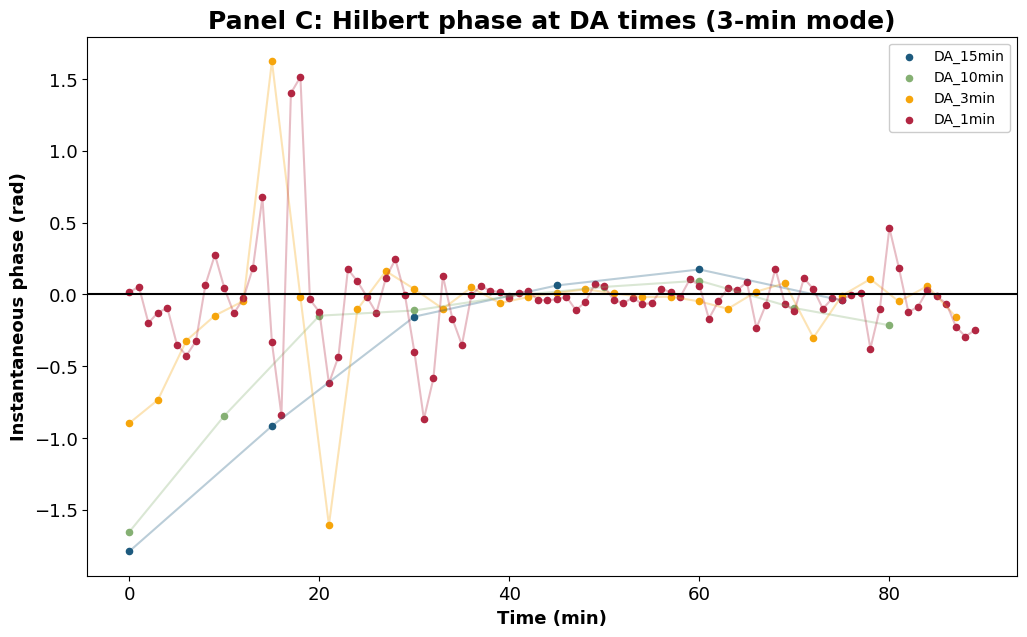

In [161]:
fig, ax = plt.subplots(1, figsize=(12,7))
colors = list(cmaps.pride(np.linspace(.17,.78, len(exps))))

for i, key in enumerate(x_dict):
    x = x_dict[key]
    x_filt = bandpass_filter(x, lowcut, highcut, fs)
    analytic_signal = hilbert(x_filt)
    inst_phase = np.angle(analytic_signal)
    da_t = np.arange(time[0], time[-1], da_period_dict[key])
    da_idx = np.searchsorted(time, da_t)
    field = inst_phase[da_idx]
    grad = np.gradient(field)
    ax.plot(da_t/60, grad, color=colors[i], alpha=0.3)
    ax.scatter(da_t/60, grad, color=colors[i], label=key, s=20)
ax.set_ylabel("Instantaneous phase (rad)")
ax.set_xlabel("Time (min)")
ax.set_title("Hilbert phase at DA times (3-min mode)")
ax.legend()

ax.axhline(0, color='k')

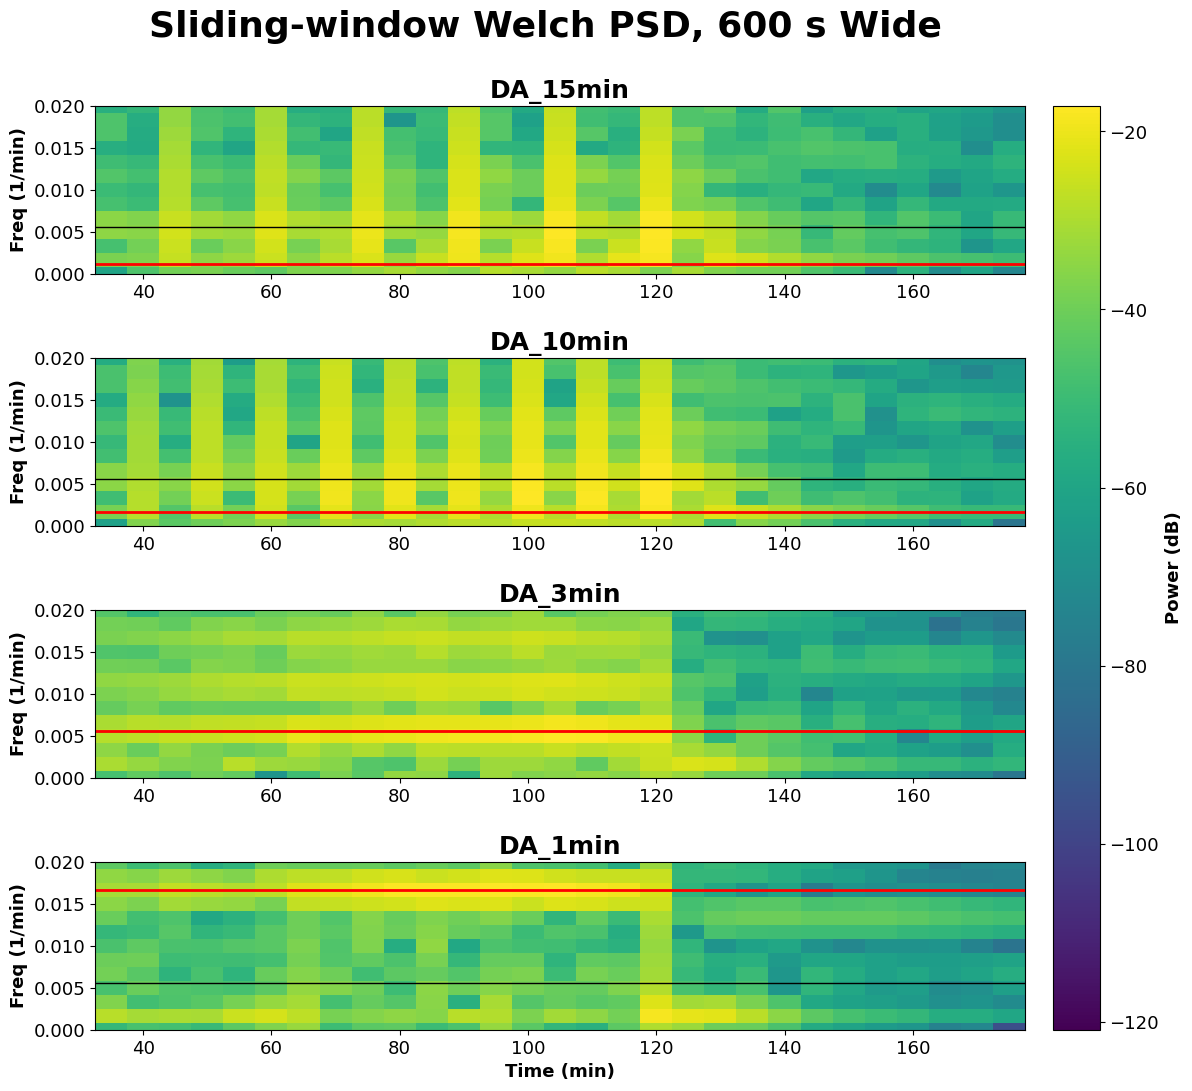

In [7]:
# --- Panel B: Sliding-window PSD ---

# Sliding PSD parameters
window_sec = 600  # 10 min window
noverlap = 0.5    # 50% overlap
nperseg = int(window_sec*fs)


fig, axes = plt.subplots(4,1, figsize=(12,12))
for i, key in enumerate(x_dict):
    x = x_dict[key]
    Sxx_list = []
    times_list = []
    step = int(nperseg*(1-noverlap))
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg]
        f, Pxx = welch(seg, fs=fs, nperseg=nperseg)
        Sxx_list.append(Pxx)
        times_list.append(time[start+nperseg//2]/60)
    Sxx = np.array(Sxx_list).T

    mask = f>0

    
    #im = axes[i].pcolormesh(times_list, 1/f[mask], 10*np.log10(Sxx[mask]), shading='auto', cmap='viridis')

    im = axes[i].pcolormesh(times_list, f, 10*np.log10(Sxx), shading='auto', cmap='viridis')
    axes[i].set_title(key)

    axes[i].axhline(1/180, linewidth=1, color='k')
    axes[i].axhline(1/da_period_dict[key], linewidth=2, color='r')

    axes[i].set_ylim(0, 0.02)

    
    axes[i].set_ylabel("Freq (1/min)")
axes[3].set_xlabel("Time (min)")
fig.suptitle(f"Sliding-window Welch PSD, {window_sec} s Wide", fontsize=26, weight='bold', y=.96)
fig.colorbar(im, ax=axes, label='Power (dB)', anchor=(1.8,0.5))

plt.subplots_adjust(hspace=0.5)


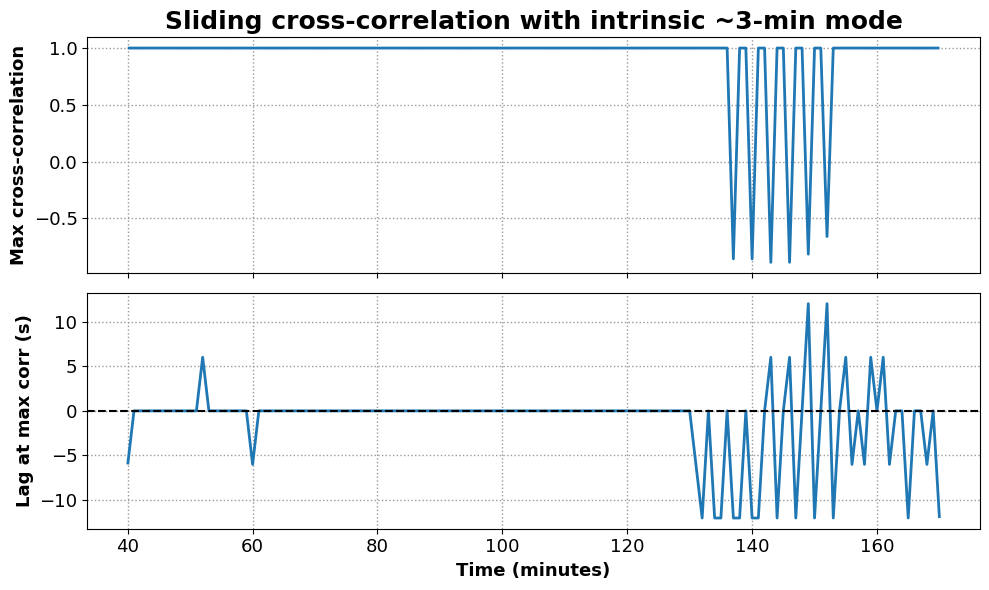

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, correlate

x = x_dict['DA_10min']
t = (wtg.time.values[i0:])*60#

# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
dt = np.median(np.diff(t))          # sampling interval (s)
T_intrinsic = 180.0                 # intrinsic period (~3 min) in seconds
window_minutes = 20                 # sliding window length (minutes)
step_minutes = 1                    # step between windows (minutes)

# --------------------------------------------------
# BANDPASS FILTER AROUND 3-MIN MODE
# --------------------------------------------------
fs = 1.0 / dt
f0 = 1.0 / T_intrinsic

bw = 0.25 * f0                      # 25% bandwidth
low = (f0 - bw) / (0.5 * fs)
high = (f0 + bw) / (0.5 * fs)

b, a = butter(4, [low, high], btype="bandpass")
x_3min = filtfilt(b, a, x)

# --------------------------------------------------
# SLIDING-WINDOW CROSS-CORRELATION
# --------------------------------------------------
win_len = int((window_minutes * 60) / dt)
step_len = int((step_minutes * 60) / dt)
max_lag = int((T_intrinsic / 2) / dt)

times = []
corr_max = []
lag_at_max = []

for start in range(0, len(x) - win_len, step_len):
    end = start + win_len

    xw = x[start:end] - np.mean(x[start:end])
    yw = x_3min[start:end] - np.mean(x_3min[start:end])

    c = correlate(xw, yw, mode="full")
    lags = np.arange(-len(xw) + 1, len(xw)) * dt

    # restrict to physically meaningful lags
    mask = np.abs(lags) <= max_lag
    c = c[mask]
    lags = lags[mask]

    c /= np.max(np.abs(c))  # normalize

    corr_max.append(np.max(c))
    lag_at_max.append(lags[np.argmax(c)])
    times.append(t[start + win_len // 2] / 60.0)  # minutes

times = np.array(times)
corr_max = np.array(corr_max)
lag_at_max = np.array(lag_at_max)

# --------------------------------------------------
# PLOTTING
# --------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(times, corr_max, lw=2)
ax[0].set_ylabel("Max cross-correlation")
ax[0].set_title("Sliding cross-correlation with intrinsic ~3-min mode")
ax[0].grid(True)

ax[1].plot(times, lag_at_max, lw=2)
ax[1].axhline(0, color="k", ls="--")
ax[1].set_ylabel("Lag at max corr (s)")
ax[1].set_xlabel("Time (minutes)")
ax[1].grid(True)

plt.tight_layout()
plt.show()


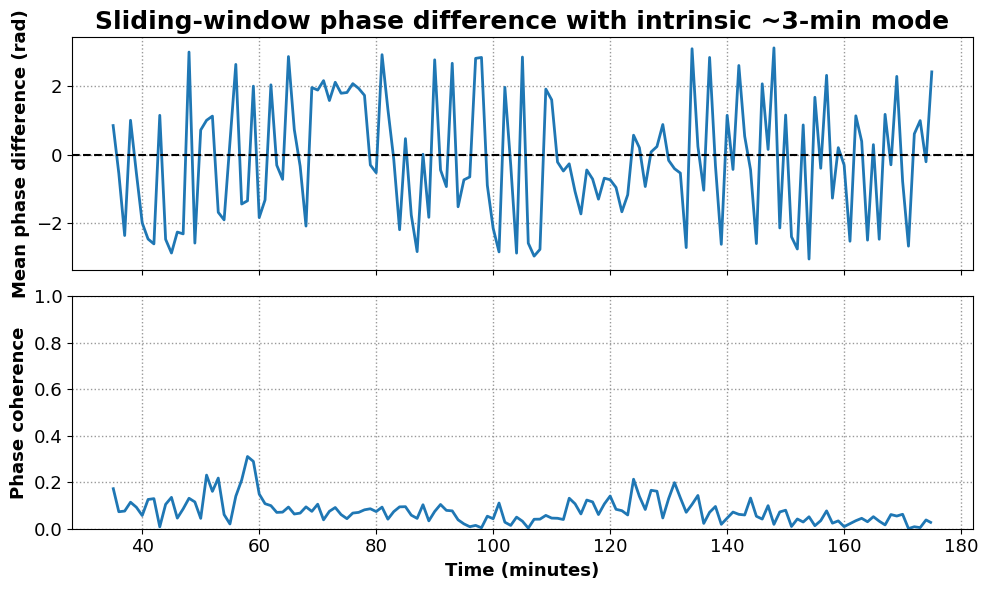

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert



x = x_dict['DA_1min']
t = (wtg.time.values[i0:])*60#

# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
dt = np.median(np.diff(t))      # sampling interval (s)
T_intrinsic = 180.0             # intrinsic period (~3 min)
window_minutes = 10             # sliding window length
step_minutes = 1                # step size

# --------------------------------------------------
# BANDPASS FILTER AROUND 3-MIN MODE
# --------------------------------------------------
fs = 1.0 / dt
f0 = 1.0 / T_intrinsic
bw = 0.25 * f0

low = (f0 - bw) / (0.5 * fs)
high = (f0 + bw) / (0.5 * fs)

b, a = butter(4, [low, high], btype="bandpass")

x_filt = filtfilt(b, a, x)

# --------------------------------------------------
# SLIDING-WINDOW PHASE DIFFERENCE
# --------------------------------------------------
win_len = int((window_minutes * 60) / dt)
step_len = int((step_minutes * 60) / dt)

times = []
phase_mean = []
phase_coherence = []

for start in range(0, len(x) - win_len, step_len):
    end = start + win_len

    # analytic signals
    hx = hilbert(x[start:end])
    hy = hilbert(x_filt[start:end])

    phi_x = np.angle(hx)
    phi_y = np.angle(hy)

    # instantaneous phase difference
    dphi = np.unwrap(phi_x - phi_y)

    # circular mean and coherence
    R = np.mean(np.exp(1j * dphi))
    phase_mean.append(np.angle(R))
    phase_coherence.append(np.abs(R))

    times.append(t[start + win_len // 2] / 60.0)

times = np.array(times)
phase_mean = np.array(phase_mean)
phase_coherence = np.array(phase_coherence)

# --------------------------------------------------
# PLOTTING
# --------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(times, phase_mean, lw=2)
ax[0].axhline(0, color="k", ls="--")
ax[0].set_ylabel("Mean phase difference (rad)")
ax[0].set_title("Sliding-window phase difference with intrinsic ~3-min mode")
ax[0].grid(True)

ax[1].plot(times, phase_coherence, lw=2)
ax[1].set_ylabel("Phase coherence")
ax[1].set_xlabel("Time (minutes)")
ax[1].set_ylim(0, 1)
ax[1].grid(True)

plt.tight_layout()
plt.show()


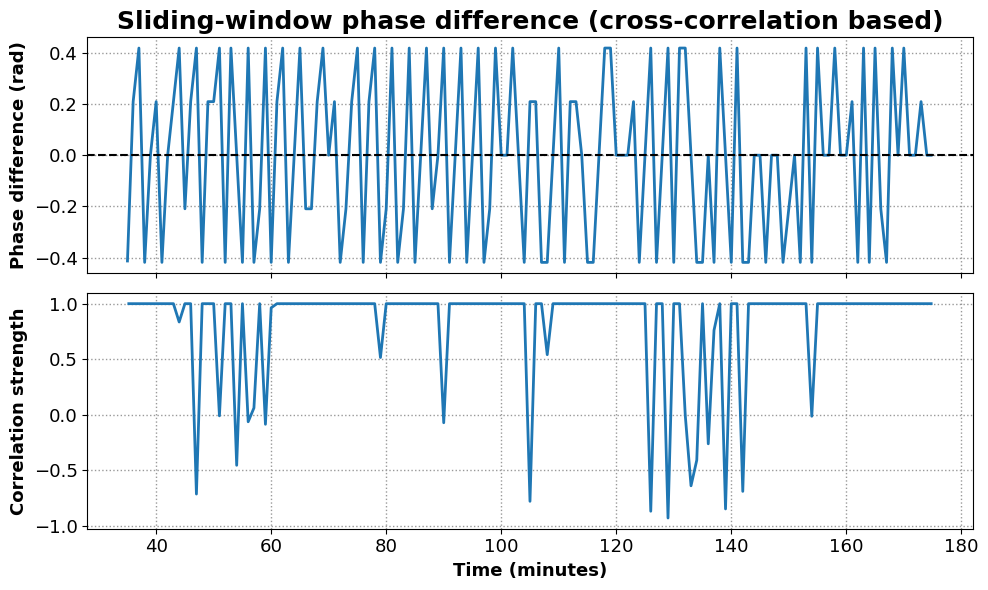

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, correlate

# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
dt = np.median(np.diff(t))      # sampling interval (s)
T_intrinsic = 180.0             # intrinsic period (~3 min)
window_minutes = 10
step_minutes = 1

# --------------------------------------------------
# BANDPASS FILTER AROUND 3-MIN MODE
# --------------------------------------------------
fs = 1.0 / dt
f0 = 1.0 / T_intrinsic
bw = 0.25 * f0

low = (f0 - bw) / (0.5 * fs)
high = (f0 + bw) / (0.5 * fs)

b, a = butter(4, [low, high], btype="bandpass")
x_3min = filtfilt(b, a, x)

# --------------------------------------------------
# SLIDING-WINDOW PHASE DIFFERENCE (XCORR-BASED)
# --------------------------------------------------
win_len = int((window_minutes * 60) / dt)
step_len = int((step_minutes * 60) / dt)
max_lag = int((T_intrinsic / 2) / dt)

times = []
phase_diff = []
corr_strength = []

for start in range(0, len(x) - win_len, step_len):
    end = start + win_len

    xw = x[start:end] - np.mean(x[start:end])
    yw = x_3min[start:end] - np.mean(x_3min[start:end])

    c = correlate(xw, yw, mode="full")
    lags = np.arange(-len(xw) + 1, len(xw)) * dt

    # restrict to reasonable lags
    mask = np.abs(lags) <= max_lag
    c = c[mask]
    lags = lags[mask]

    # normalize
    c /= np.max(np.abs(c))

    # lag at max correlation
    tau = lags[np.argmax(c)]

    # convert lag to phase
    phi = 2.0 * np.pi * tau / T_intrinsic

    # wrap to [-pi, pi]
    phi = (phi + np.pi) % (2 * np.pi) - np.pi

    phase_diff.append(phi)
    corr_strength.append(np.max(c))
    times.append(t[start + win_len // 2] / 60.0)

times = np.array(times)
phase_diff = np.array(phase_diff)
corr_strength = np.array(corr_strength)

# --------------------------------------------------
# PLOTTING
# --------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(times, phase_diff, lw=2)
ax[0].axhline(0, color="k", ls="--")
ax[0].set_ylabel("Phase difference (rad)")
ax[0].set_title("Sliding-window phase difference (cross-correlation based)")
ax[0].grid(True)

ax[1].plot(times, corr_strength, lw=2)
ax[1].set_ylabel("Correlation strength")
ax[1].set_xlabel("Time (minutes)")
#ax[1].set_ylim(0, 1)
ax[1].grid(True)

plt.tight_layout()
plt.show()


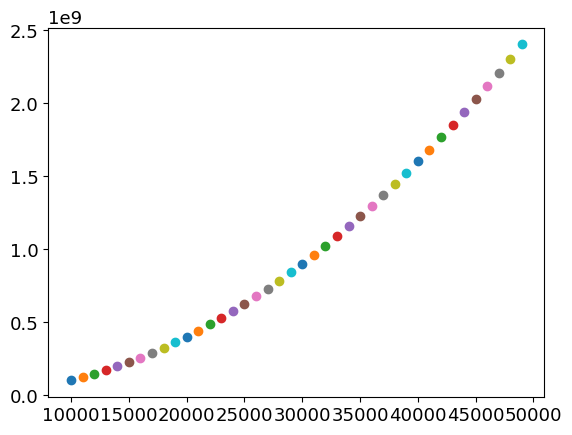

In [237]:
H = np.arange(10000, 50000, 1000)

for h in np.arange(10000, 50000, 1000):
    plt.scatter(h, 1/((1/h)**2))

# Increments and sound waves

In [65]:
exp = 'C03_H09_V4'

In [66]:
inc = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/increments.nc")

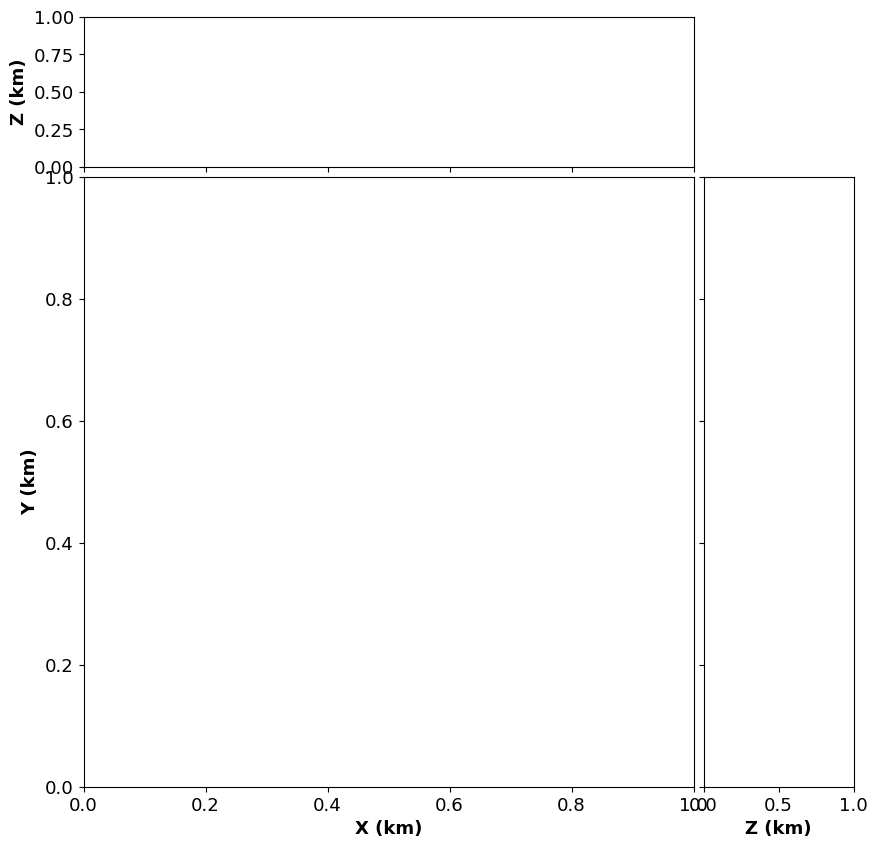

In [68]:
def make_plan_plot():
    fig, main_ax = plt.subplots(figsize=(10,10))#, facecolor='none')
    divider = make_axes_locatable(main_ax)
    top_ax = divider.append_axes("top", 1.5, pad=0.1, sharex=main_ax)
    right_ax = divider.append_axes("right", 1.5, pad=0.1, sharey=main_ax)

    # make some labels invisible
    top_ax.xaxis.set_tick_params(labelbottom=False)
    right_ax.yaxis.set_tick_params(labelleft=False)

    main_ax.set_xlabel('X (km)')
    main_ax.set_ylabel('Y (km)')
    top_ax.set_ylabel( 'Z (km)')
    right_ax.set_xlabel('Z (km)')
    main_ax.set_aspect('equal')
    
    return fig, main_ax, right_ax, top_ax


fig, main_ax, right_ax, top_ax =make_plan_plot()


C03_H18_V4


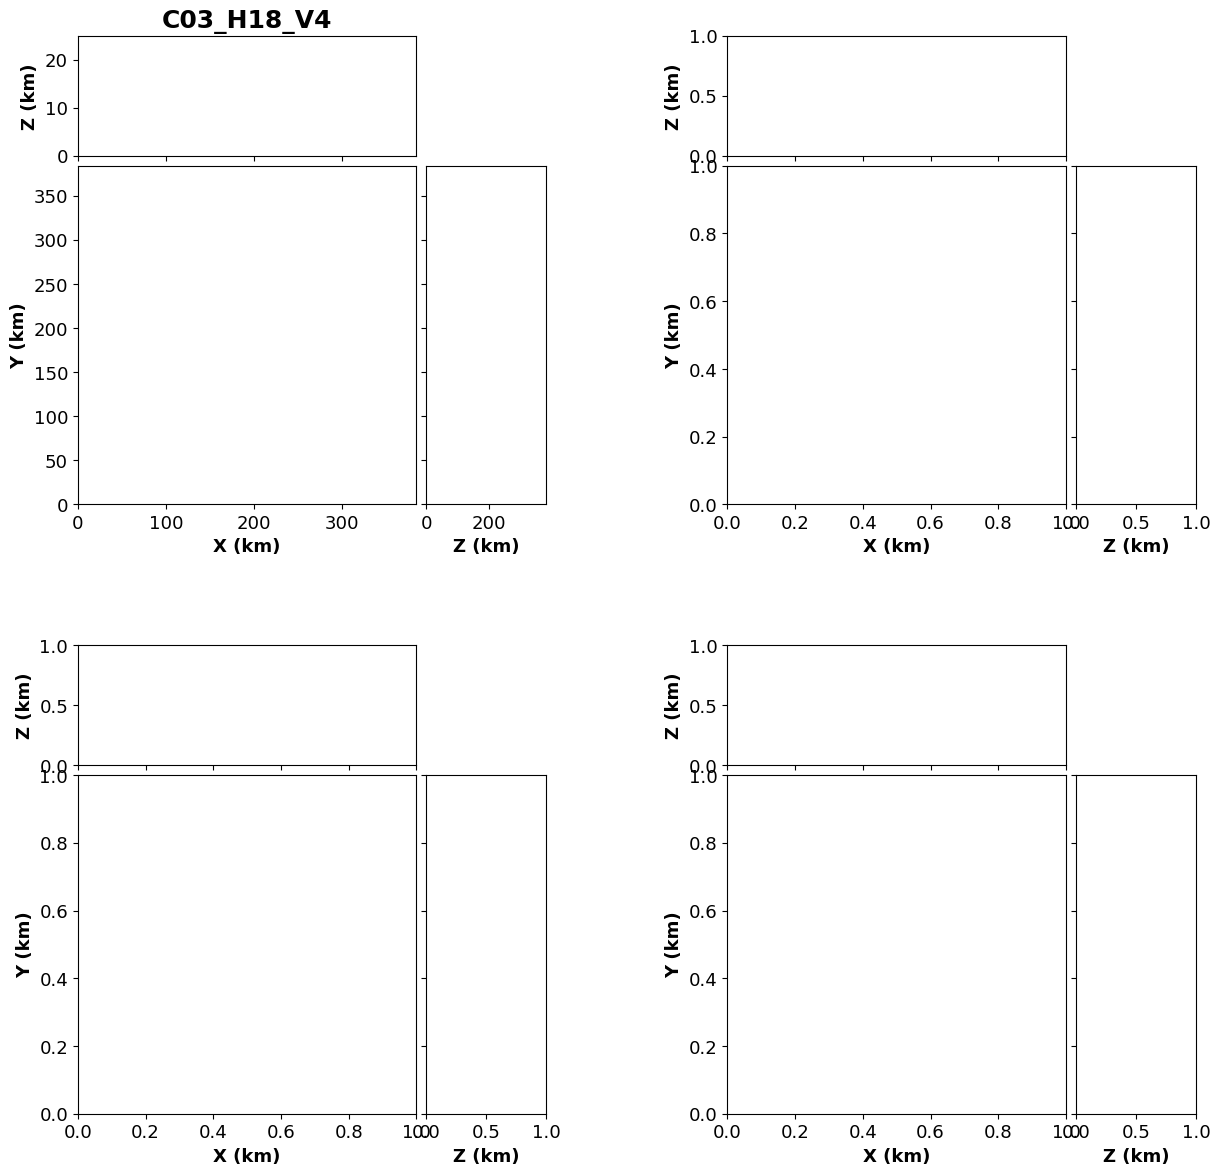

In [105]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --------------------------------------------------
# Create 2x2 grid of MAIN axes
# --------------------------------------------------
fig, main_axes = plt.subplots(2, 2, figsize=(16, 14))

axes_blocks = []  # will store dictionaries of axes

for i in range(2):
    row = []
    for j in range(2):

        main_ax = main_axes[i, j]
        divider = make_axes_locatable(main_ax)

        # Attach top and right axes
        top_ax = divider.append_axes("top", size=1.2, pad=0.1, sharex=main_ax)
        right_ax = divider.append_axes("right", size=1.2, pad=0.1, sharey=main_ax)

        # Hide redundant tick labels
        top_ax.xaxis.set_tick_params(labelbottom=False)
        right_ax.yaxis.set_tick_params(labelleft=False)

        # Labels
        main_ax.set_xlabel('X (km)')
        main_ax.set_ylabel('Y (km)')
        top_ax.set_ylabel('Z (km)')
        right_ax.set_xlabel('Z (km)')

        main_ax.set_aspect('equal')

        row.append({
            "main": main_ax,
            "top": top_ax,
            "right": right_ax
        })

    axes_blocks.append(row)

plt.subplots_adjust(wspace=0.1, hspace=0.3)
#plt.show

axes_blocks_flat = [block for row in axes_blocks for block in row]


exps = ['C03_H18_V4']#,'C03_H09_V4','C03_H09_V2']#, 'C03_H09_V2_fine']

t = 10
z = 10
for i,exp in enumerate(exps):
    print(exp)
    m = axes_blocks_flat[i]
    inc = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/increments.nc")

    if i == 0:
        Xx, Zx = np.meshgrid(inc.xh.values, inc.z.values)
        Yy, Zy = np.meshgrid(inc.yh.values, inc.z.values)
        X,  Y  = np.meshgrid(inc.xh.values, inc.yh.values)

    var = inc.th.values
    mask = np.where(abs(var)!=0.0, abs(var), np.nan)
   

    # top plot
    #m['top'].pcolormesh(Xx, Zx, mask[t, :, :,:].mean(axis=-2), vmin=0, vmax=1)
    m['main'].pcolormesh(X, Y, mask[t, :, :,:].mean(axis=-3))#, vmin=0, vmax=1)
   # m['right'].pcolormesh(Yy, Zy, mask[t, :, :,:].mean(axis=-1), vmin=0, vmax=1)

    m['top'].set_title(exp)

    inc.close()
    

    
    





In [106]:
np.shape(axes_blocks)mask

SyntaxError: invalid syntax (3768702144.py, line 1)

In [96]:
maxes

[{'main': <Axes: xlabel='X (km)', ylabel='Y (km)'>,
  'top': <Axes: ylabel='Z (km)'>,
  'right': <Axes: xlabel='Z (km)'>},
 {'main': <Axes: xlabel='X (km)', ylabel='Y (km)'>,
  'top': <Axes: ylabel='Z (km)'>,
  'right': <Axes: xlabel='Z (km)'>}]

/tmp/ipykernel_21837/1228938716.py:7: RuntimeWarning: Mean of empty slice
  u = np.nanmean(umask[t], axis=-1)


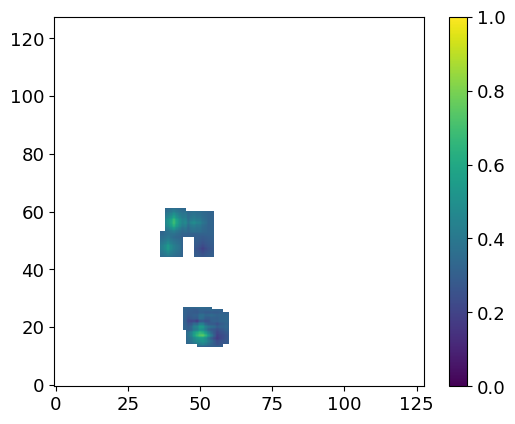

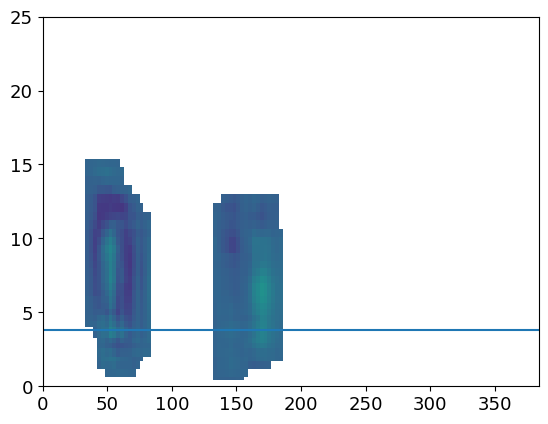

In [107]:
# first, mask out non zero values


umask = np.where(abs(var)!=0.0, abs(var), np.nan)

t=10
u = np.nanmean(umask[t], axis=-1)

yz, zz = np.meshgrid(inc.yh.values, inc.z.values)

z=13

plt.figure()
plt.imshow(abs(umask[t, z]), origin='lower', vmin=0, vmax=1)
plt.colorbar()

plt.figure()
plt.pcolormesh(yz, zz, u, vmin=0, vmax=1)
plt.axhline(inc.z[z])

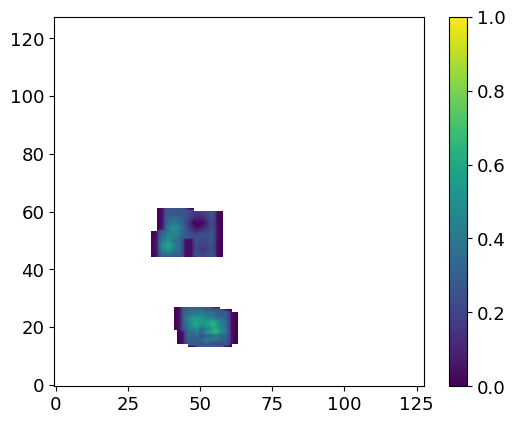

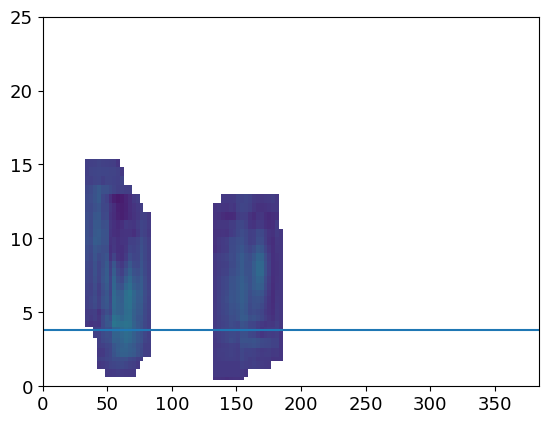

In [55]:
z=13

plt.figure()
plt.imshow(abs(umask[t, z]), origin='lower', vmin=0, vmax=1)
plt.colorbar()

plt.figure()
plt.pcolormesh(yz, zz, u, vmin=0, vmax=1)
plt.axhline(inc.z[z])

In [34]:
np.any(np.isnan(u[t])==False)

np.True_

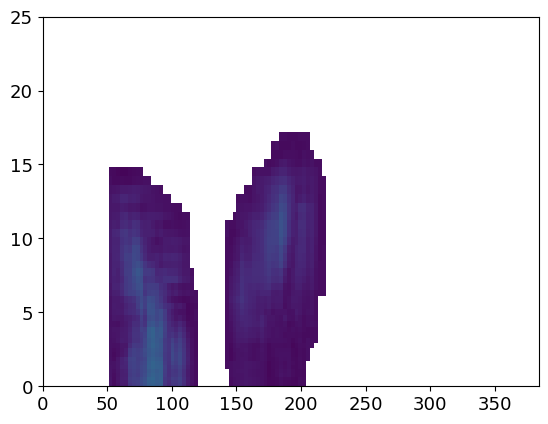